# IPA Nigeria – Associate Research & Policy Manager
## Data Skills Assessment | NCC Complaints Data 2024
**Candidate:** Tolulope Olowolaju
**Software:** Python (pandas, numpy, scipy, matplotlib, seaborn)
**Dataset:** ncc_complaints_2024.csv

---
### Assessment Structure
| Part | Focus |
|------|-------|
| 1 | Data Cleaning & Management |
| 2 | Data Wrangling & Analysis (EDA — univariate, bivariate, statistical testing) |
| 3 | Data Visualisation |

> Charts are saved automatically to `./charts` (created on first run, relative to
> this notebook). Just run the cells top to bottom.


## importing libraries

In [1]:
# -----------------------------------------------------------------------
# 0.1  Imports
# -----------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from matplotlib.gridspec import GridSpec
from IPython.display import display

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------
# 0.2  Chart output directory (relative, so it works on any machine)
# -----------------------------------------------------------------------
CHART_DIR = os.path.join(os.getcwd(), 'charts')
os.makedirs(CHART_DIR, exist_ok=True)
print(f'Charts will be saved to: {CHART_DIR}')

# -----------------------------------------------------------------------
# 0.3  Global aesthetics
# -----------------------------------------------------------------------
PROVIDER_COLORS = {
    'MTN':     '#FFCC00',
    'Airtel':  '#E30613',
    'Glo':     '#009A44',
    '9Mobile': '#7B2D8B',
}
CATEGORY_PALETTE = sns.color_palette('tab10', 10)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
})

def save_fig(fig, filename):
    '''Save a figure to the charts folder and display it inline.'''
    path = os.path.join(CHART_DIR, filename)
    fig.savefig(path)
    print(f'  Saved: {path}')
    plt.show()
    plt.close(fig)

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

print('Setup complete.')


Charts will be saved to: C:\Users\USER\Desktop\ioppppaaaa2\charts
Setup complete.


---
##  Data Cleaning


In [2]:
# -----------------------------------------------------------------------
# Task 1.1 -- Import dataset and inspect structure
# NOTE: place ncc_complaints_2024.csv in the same folder as this notebook,
# or update RAW_PATH below.
# -----------------------------------------------------------------------
RAW_PATH = 'ncc_complaints_2024.csv'

raw = pd.read_csv(RAW_PATH)

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Shape (rows x cols): {raw.shape}')
print(f'Columns: {list(raw.columns)}')
print()
print('--- Data Types ---')
print(raw.dtypes)
print()
print('--- First 5 rows ---')
display(raw.head())
print()
print('--- Last 5 rows ---')
display(raw.tail())


DATASET OVERVIEW
Shape (rows x cols): (4203, 14)
Columns: ['complaint_id', 'provider', 'channel', 'complaint_category', 'complaint_subcategory', 'state', 'geopolitical_zone', 'gender', 'age', 'date_created', 'date_resolved', 'resolution_time_minutes', 'status', 'satisfaction_score']

--- Data Types ---
complaint_id                object
provider                    object
channel                     object
complaint_category          object
complaint_subcategory       object
state                       object
geopolitical_zone           object
gender                      object
age                        float64
date_created                object
date_resolved               object
resolution_time_minutes      int64
status                      object
satisfaction_score         float64
dtype: object

--- First 5 rows ---


,complaint_id,provider,channel,complaint_category,complaint_subcategory,state,geopolitical_zone,gender,age,date_created,date_resolved,resolution_time_minutes,status,satisfaction_score
0,C002909,Airtel,Call Center,Mobile Money,Unable to Pay Bill,Abuja FCT,North Central,Male,37.0,2024-06-04 07:39,2024-06-04 07:49,10,Resolved,4.0
1,C002483,MTN,Call Center,Mobile Money,Unable to Pay Bill,Abuja FCT,North Central,Female,33.0,2024-05-07 14:43,2024-05-07 14:53,10,Resolved,4.0
2,C001006,Airtel,Call Center,Billing,Recharge Failed,Bayelsa,South South,Female,19.0,2024-01-28 06:43,2024-01-30 05:45,2822,Escalated,NaN
3,C004446,Glo,Call Center,Data/Internet,Slow Speed,Sokoto,North West,Female,18.0,2024-11-20 07:55,2024-11-20 08:12,17,Resolved,3.0
4,C001803,Airtel,Call Center,Mobile Money,Agent Issue,Ekiti,South West,Male,39.0,2024-03-02 12:14,2024-03-02 12:19,5,Resolved,3.0



--- Last 5 rows ---


,complaint_id,provider,channel,complaint_category,complaint_subcategory,state,geopolitical_zone,gender,age,date_created,date_resolved,resolution_time_minutes,status,satisfaction_score
4198,C001498,Airtel Nigeria,Call Center,Network,Weak Signal,NaN,NaN,NaN,27.0,2024-02-22 14:19,2024-02-23 19:07,1728,Pending,NaN
4199,C005076,9Mobile,Call Center,Voice/Calls,Roaming Issue,Lagos,South West,Female,37.0,2024-12-04 10:03,2024-12-04 15:23,320,Resolved,3.0
4200,C003955,mtn,Call Center,Mobile Money,Agent Issue,Lagos,South West,Male,29.0,2024-09-12 13:31,2024-09-12 13:36,5,Resolved,4.0
4201,C003411,MTN,Call Center,Mobile Money,PIN Reset,Benue,North Central,Male,35.0,2024-07-03 06:26,2024-07-03 06:46,20,Resolved,4.0
4202,C002126,Airtel,Social Media,VAS,Loan Deduction,Abuja FCT,North Central,Male,34.0,2024-04-01 12:33,2024-04-08 03:32,9539,Pending,NaN


In [3]:
# -----------------------------------------------------------------------
# Missing values summary
# -----------------------------------------------------------------------
missing = pd.DataFrame({
    'Missing Count': raw.isnull().sum(),
    'Missing %': (raw.isnull().sum() / len(raw) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('--- Missing Values per Variable ---')
display(missing)
print()
miss_vars = missing[missing['Missing %'] > 0]
print('Variables with any missing data (most to least):')
print(miss_vars.index.tolist())
print()

top_missing_var = miss_vars.index[0]
print(f'"{top_missing_var}" has by far the most missing data '
      f'({miss_vars.iloc[0]["Missing %"]:.1f}%).')
print()

# Is satisfaction_score's gap a data-quality problem, or just how the field works
# (only resolved complaints get rated)?
sat_by_status = raw.groupby('status')['satisfaction_score'].apply(lambda s: s.notna().mean() * 100).round(1)
print('--- satisfaction_score completeness by status (%) ---')
print(sat_by_status)
print()
non_resolved_completeness = sat_by_status.drop('Resolved', errors='ignore')
if sat_by_status.get('Resolved', 0) > 99 and non_resolved_completeness.max() < 1:
    print('satisfaction_score is only populated for Resolved complaints (100%) and')
    print('essentially never for Pending/Escalated ones. So this "missingness" is by')
    print('design, not a data quality issue, and it should not be imputed.')
print()

# Same question for state / geopolitical_zone -- missing together, or separately?
joint_missing = int((raw['state'].isna() & raw['geopolitical_zone'].isna()).sum())
either_missing = int((raw['state'].isna() | raw['geopolitical_zone'].isna()).sum())
print(f'state and geopolitical_zone are missing on the exact same {joint_missing} '
      f'records ({either_missing} missing on either one alone), which looks like an '
      f'unregistered SIM rather than a random gap.')


--- Missing Values per Variable ---


,Missing Count,Missing %
satisfaction_score,944,22.46
gender,226,5.38
state,161,3.83
geopolitical_zone,161,3.83
age,151,3.59
complaint_id,0,0.00
provider,0,0.00
channel,0,0.00
complaint_category,0,0.00
complaint_subcategory,0,0.00



Variables with any missing data (most to least):
['satisfaction_score', 'gender', 'state', 'geopolitical_zone', 'age']

"satisfaction_score" has by far the most missing data (22.5%).

--- satisfaction_score completeness by status (%) ---
status
Escalated      0.0
Pending        0.0
Resolved     100.0
Name: satisfaction_score, dtype: float64

satisfaction_score is only populated for Resolved complaints (100%) and
essentially never for Pending/Escalated ones. So this "missingness" is by
design, not a data quality issue, and it should not be imputed.

state and geopolitical_zone are missing on the exact same 161 records (161 missing on either one alone), which looks like an unregistered SIM rather than a random gap.


### Standardisation & Deduplication

In [ ]:
# -----------------------------------------------------------------------
#  Examine and standardise 'provider'
# -----------------------------------------------------------------------
print('--- Raw provider values (before cleaning) ---')
print(raw['provider'].value_counts().to_string())
print()

# Collapse every naming variant down to 4 canonical names
PROVIDER_MAP = {
    'MTN':           'MTN',
    'MTN Nigeria':   'MTN',
    'MTN NG':        'MTN',
    'mtn':           'MTN',
    'Airtel':        'Airtel',
    'Airtel Nigeria':'Airtel',
    'AIRTEL':        'Airtel',
    'airtel':        'Airtel',
    'Glo':           'Glo',
    '9Mobile':       '9Mobile',
}

df = raw.copy()
df['provider'] = df['provider'].map(PROVIDER_MAP).fillna(df['provider'])

print('--- Provider values AFTER standardisation ---')
print(df['provider'].value_counts().to_string())
print()
print(f'Unique providers remaining: {df["provider"].nunique()}')

assert df['provider'].isin(['MTN', 'Airtel', 'Glo', '9Mobile']).all(), \
    'Some provider values did not map -- extend PROVIDER_MAP.'
print('\nAll records now map to one of the 4 providers.')


--- Raw provider values (before cleaning) ---
provider
MTN               1787
Airtel            1425
Glo                483
9Mobile            307
MTN Nigeria         41
MTN NG              39
mtn                 36
airtel              33
Airtel Nigeria      26
AIRTEL              26

--- Provider values AFTER standardisation ---
provider
MTN        1903
Airtel     1510
Glo         483
9Mobile     307

Unique providers remaining: 4

All records now map to one of the 4 providers.


In [ ]:
# -----------------------------------------------------------------------
#  -- Identify and remove duplicate records
# Criterion: same complaint_id (primary key)
# -----------------------------------------------------------------------
n_before = len(df)
dup_mask = df.duplicated(subset=['complaint_id'], keep='first')
n_dups = dup_mask.sum()

print(f'Records before deduplication    : {n_before:,}')
print(f'Duplicate rows (same complaint_id): {n_dups}')

df = df[~dup_mask].reset_index(drop=True)
print(f'Records after deduplication     : {len(df):,}')

# Also check for full-row duplicates
full_dups = df.duplicated().sum()
print(f'Remaining full-row duplicates   : {full_dups}')
if full_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed {full_dups} full-row duplicates.')

# Quick sanity check: are these actual duplicate rows, or two different
# complaints that just happen to share an ID?
exact_dups_on_raw = raw.duplicated().sum()
print(f'\nFull-row duplicates on the raw file: {exact_dups_on_raw}')
print('Same number as the duplicate complaint_ids above, so these are genuine repeat submissions.')


Records before deduplication    : 4,203
Duplicate rows (same complaint_id): 117
Records after deduplication     : 4,086
Remaining full-row duplicates   : 0

Full-row duplicates on the raw file: 117
Same number as the duplicate complaint_ids above, so these are genuine repeat submissions.


### Data Validation

In [ ]:
# -----------------------------------------------------------------------
# 
# Age validation
# -----------------------------------------------------------------------
df['age'] = pd.to_numeric(df['age'], errors='coerce')

implausible_age = (df['age'] < 15) | (df['age'] > 100)
print(f'Implausible age values (< 15 or > 100): {implausible_age.sum()} records')
print('Example values:', df.loc[implausible_age, 'age'].value_counts().head(8).to_dict())
print()

# Set to NaN rather than dropping the row -- keeps the complaint for every other analysis
df.loc[implausible_age, 'age'] = np.nan
print(f'Age missing after cleaning: {df["age"].isna().sum()} ({df["age"].isna().mean()*100:.1f}%)')
print(f'Valid age range: {df["age"].min():.0f} - {df["age"].max():.0f}')


Implausible age values (< 15 or > 100): 32 records
Example values: {999.0: 10, 150.0: 9, -1.0: 8, 5.0: 5}

Age missing after cleaning: 179 (4.4%)
Valid age range: 18 - 74


In [7]:
# -----------------------------------------------------------------------
# Task 1.3b -- Date validation
# -----------------------------------------------------------------------
df['date_created']  = pd.to_datetime(df['date_created'],  errors='coerce')
df['date_resolved'] = pd.to_datetime(df['date_resolved'], errors='coerce')

bad_dates = df['date_resolved'] < df['date_created']
print(f'Records where date_resolved < date_created: {bad_dates.sum()}')

# Null out the two date-related fields, but keep the complaint and its status --
# the dates were the problem, not the complaint itself.
df.loc[bad_dates, 'date_resolved'] = np.nan
df.loc[bad_dates, 'resolution_time_minutes'] = np.nan
print(f'Nullified resolution date for {bad_dates.sum()} records.')

# Derived time columns used throughout the analysis
df['month']               = df['date_created'].dt.to_period('M')
df['month_num']           = df['date_created'].dt.month
df['month_name']          = df['date_created'].dt.strftime('%b')
df['hour']                = df['date_created'].dt.hour
df['dow']                 = df['date_created'].dt.day_name()
df['resolution_time_hours'] = df['resolution_time_minutes'] / 60
print('Time columns derived: month, month_num, month_name, hour, dow, resolution_time_hours')


Records where date_resolved < date_created: 89

Nullified resolution date for 89 records.


Time columns derived: month, month_num, month_name, hour, dow, resolution_time_hours


In [8]:
# -----------------------------------------------------------------------
# Task 1.3c -- FCR flag, gender standardisation, save clean dataset
# -----------------------------------------------------------------------
df['fcr'] = (df['resolution_time_minutes'] <= 15) & (df['status'] == 'Resolved')
print('FCR here = Resolved status AND resolved within 15 minutes.')
print()

# Standardise gender capitalisation
df['gender'] = df['gender'].str.strip().str.title()

CLEAN_PATH = 'ncc_complaints_2024_clean.csv'
df.to_csv(CLEAN_PATH, index=False)

print('=' * 60)
print('CLEANING SUMMARY')
print('=' * 60)
print(f'Raw records              : {len(raw):,}')
print(f'Duplicate IDs removed    : {n_dups}')
print(f'Final clean dataset      : {len(df):,} records')
print(f'Saved to                 : {CLEAN_PATH}')
print()
print('--- Missing values in clean dataset ---')
miss_clean = df.isnull().sum()
display(miss_clean[miss_clean > 0].to_frame('Missing'))


FCR here = Resolved status AND resolved within 15 minutes.



CLEANING SUMMARY
Raw records              : 4,203
Duplicate IDs removed    : 117
Final clean dataset      : 4,086 records
Saved to                 : ncc_complaints_2024_clean.csv

--- Missing values in clean dataset ---


,Missing
state,157
geopolitical_zone,157
gender,218
age,179
date_resolved,89
resolution_time_minutes,89
satisfaction_score,921
resolution_time_hours,89


---
## Part 2 — Data Wrangling & Analysis
### Task 2.1  Complaint Volumes

In [9]:
# -----------------------------------------------------------------------
# Task 2.1a -- Total complaints per provider vs expected market share
# -----------------------------------------------------------------------
EXPECTED_SHARE = {'MTN': 0.40, 'Airtel': 0.27, 'Glo': 0.20, '9Mobile': 0.13}

vol = df['provider'].value_counts().reset_index()
vol.columns = ['Provider', 'Complaints']
vol['Actual Share (%)']   = (vol['Complaints'] / vol['Complaints'].sum() * 100).round(1)
vol['Expected Share (%)'] = vol['Provider'].map(EXPECTED_SHARE).mul(100)
vol['Deviation (pp)']     = (vol['Actual Share (%)'] - vol['Expected Share (%)']).round(1)
vol = vol.sort_values('Deviation (pp)', ascending=False).reset_index(drop=True)

print('--- Complaints Volume vs Expected Market Share ---')
display(vol)
print()

over_rep  = vol[vol['Deviation (pp)'] > 0]
under_rep = vol[vol['Deviation (pp)'] < 0]

print('Above their expected share:')
for _, row in over_rep.iterrows():
    print(f'  - {row["Provider"]}: {row["Actual Share (%)"]:.1f}% actual vs '
          f'{row["Expected Share (%)"]:.0f}% expected (+{row["Deviation (pp)"]:.1f}pp)')
print('Below their expected share:')
for _, row in under_rep.iterrows():
    print(f'  - {row["Provider"]}: {row["Actual Share (%)"]:.1f}% actual vs '
          f'{row["Expected Share (%)"]:.0f}% expected ({row["Deviation (pp)"]:.1f}pp)')
print()
print(f'{over_rep.iloc[0]["Provider"]} has the biggest gap from its expected share,')
print('a bit more than MTN. Could be a genuinely higher fault rate, could be that')
print('their subscribers are more aware of how to complain, or the market-share')
print('figures we were given are just rough estimates. Worth following up on rather')
print('than reading too much into volume alone -- the stats section below checks')
print('whether the complaint mix itself differs by provider.')


--- Complaints Volume vs Expected Market Share ---


,Provider,Complaints,Actual Share (%),Expected Share (%),Deviation (pp)
0,Airtel,1465,35.9,27.0,8.9
1,MTN,1851,45.3,40.0,5.3
2,9Mobile,300,7.3,13.0,-5.7
3,Glo,470,11.5,20.0,-8.5



Above their expected share:
  - Airtel: 35.9% actual vs 27% expected (+8.9pp)
  - MTN: 45.3% actual vs 40% expected (+5.3pp)
Below their expected share:
  - 9Mobile: 7.3% actual vs 13% expected (-5.7pp)
  - Glo: 11.5% actual vs 20% expected (-8.5pp)

Airtel has the biggest gap from its expected share,
a bit more than MTN. Could be a genuinely higher fault rate, could be that
their subscribers are more aware of how to complain, or the market-share
figures we were given are just rough estimates. Worth following up on rather
than reading too much into volume alone -- the stats section below checks
whether the complaint mix itself differs by provider.


In [10]:
# -----------------------------------------------------------------------
# Task 2.1b -- Cross-tabulation: complaint_category x provider
# -----------------------------------------------------------------------
xtab = pd.crosstab(df['complaint_category'], df['provider'],
                   margins=True, margins_name='TOTAL')
print('--- Complaint Category x Provider (Count) ---')
display(xtab)
print()

xtab_pct = pd.crosstab(df['complaint_category'], df['provider'],
                       normalize='columns').mul(100).round(1)
print('--- Complaint Category x Provider (% of provider total) ---')
display(xtab_pct)
print()
print('--- Top category per provider ---')
for prov in ['MTN', 'Airtel', 'Glo', '9Mobile']:
    if prov in xtab_pct.columns:
        top = xtab_pct[prov].idxmax()
        pct = xtab_pct[prov].max()
        print(f'  {prov:8s}: {top} ({pct:.1f}%)')


--- Complaint Category x Provider (Count) ---


provider,9Mobile,Airtel,Glo,MTN,TOTAL
complaint_category,,,,,
Billing,48,164,60,223,495
Data/Internet,42,200,70,297,609
Device,12,44,7,66,129
Fraud,31,156,48,154,389
Mobile Money,58,352,123,475,1008
Network,16,80,20,90,206
Other,9,25,11,30,75
SIM Issues,22,133,31,142,328
VAS,11,80,23,84,198



--- Complaint Category x Provider (% of provider total) ---


provider,9Mobile,Airtel,Glo,MTN
complaint_category,,,,
Billing,16.0,11.2,12.8,12.0
Data/Internet,14.0,13.7,14.9,16.0
Device,4.0,3.0,1.5,3.6
Fraud,10.3,10.6,10.2,8.3
Mobile Money,19.3,24.0,26.2,25.7
Network,5.3,5.5,4.3,4.9
Other,3.0,1.7,2.3,1.6
SIM Issues,7.3,9.1,6.6,7.7
VAS,3.7,5.5,4.9,4.5



--- Top category per provider ---
  MTN     : Mobile Money (25.7%)
  Airtel  : Mobile Money (24.0%)
  Glo     : Mobile Money (26.2%)
  9Mobile : Mobile Money (19.3%)


### Task 2.2  Resolution Analysis

In [11]:
# -----------------------------------------------------------------------
# Task 2.2a -- First-Contact Resolution (FCR) rate by provider
# FCR = complaint resolved (status=Resolved) within 15 minutes
# -----------------------------------------------------------------------
fcr_by_provider = (
    df.groupby('provider')['fcr']
      .agg(Total='count', FCR_Count='sum')
      .assign(**{'FCR_Rate_pct': lambda x: (x['FCR_Count'] / x['Total'] * 100).round(1)})
      .sort_values('FCR_Rate_pct', ascending=False)
      .reset_index()
)

print('--- First-Contact Resolution Rate by Provider ---')
display(fcr_by_provider)
print()

fcr_range = fcr_by_provider['FCR_Rate_pct'].max() - fcr_by_provider['FCR_Rate_pct'].min()
print(f'Range across providers: {fcr_range:.1f} points '
      f'({fcr_by_provider["FCR_Rate_pct"].min():.1f}%-{fcr_by_provider["FCR_Rate_pct"].max():.1f}%).')
if fcr_range < 10:
    print("That's fairly narrow -- provider isn't really what's driving FCR here.")
    print('The channel breakdown below tells a very different story.')
else:
    print("That's a wide range -- FCR performance really does differ by provider,")
    print('which points to uneven investment in front-line resolution.')


--- First-Contact Resolution Rate by Provider ---


,provider,Total,FCR_Count,FCR_Rate_pct
0,Glo,470,196,41.7
1,Airtel,1465,581,39.7
2,MTN,1851,730,39.4
3,9Mobile,300,112,37.3



Range across providers: 4.4 points (37.3%-41.7%).
That's fairly narrow -- provider isn't really what's driving FCR here.
The channel breakdown below tells a very different story.


In [12]:
# -----------------------------------------------------------------------
# Extra check -- FCR by channel (not explicitly asked for, but worth a look)
# -----------------------------------------------------------------------
fcr_by_channel = (
    df.groupby('channel')['fcr']
      .agg(Total='count', FCR_Count='sum')
      .assign(**{'FCR_Rate_pct': lambda x: (x['FCR_Count'] / x['Total'] * 100).round(1)})
      .sort_values('FCR_Rate_pct', ascending=False)
      .reset_index()
)
print('--- First-Contact Resolution Rate by Channel ---')
display(fcr_by_channel)
print()

chi2, p_val, dof, _ = stats.chi2_contingency(pd.crosstab(df['channel'], df['fcr']))
print(f'Chi-square (FCR x channel): chi2={chi2:.1f}, dof={dof}, p={p_val:.2e}')
print()

top_channel = fcr_by_channel.iloc[0]
rest = fcr_by_channel.iloc[1:]
print(f'{top_channel["channel"]} resolves {top_channel["FCR_Rate_pct"]:.1f}% of complaints '
      f'within 15 minutes. Every other channel manages only '
      f'{rest["FCR_Rate_pct"].min():.1f}-{rest["FCR_Rate_pct"].max():.1f}%. That gap is')
print('statistically significant and much bigger than anything we saw between')
print("providers -- channel is doing most of the work here, not the network.")


--- First-Contact Resolution Rate by Channel ---


,channel,Total,FCR_Count,FCR_Rate_pct
0,Call Center,3294,1604,48.7
1,USSD,101,3,3.0
2,Email,160,4,2.5
3,Social Media,336,6,1.8
4,In-Person,195,2,1.0



Chi-square (FCR x channel): chi2=584.7, dof=4, p=3.17e-125

Call Center resolves 48.7% of complaints within 15 minutes. Every other channel manages only 1.0-3.0%. That gap is
statistically significant and much bigger than anything we saw between
providers -- channel is doing most of the work here, not the network.


In [13]:
# -----------------------------------------------------------------------
# Task 2.2b -- Median resolution time by complaint_category
#              (only non-FCR complaints -- those taking > 15 min)
# -----------------------------------------------------------------------
non_fcr = df[
    (df['resolution_time_minutes'] > 15) &
    (df['resolution_time_minutes'].notna())
]

med_res = (
    non_fcr.groupby('complaint_category')['resolution_time_hours']
           .agg(
               Count='count',
               Median_Hours='median',
               P75_Hours=lambda x: x.quantile(0.75)
           )
           .round(2)
           .sort_values('Median_Hours', ascending=False)
           .reset_index()
)

print('--- Median Resolution Time by Category (non-FCR only) ---')
display(med_res)
print()

top3 = med_res.head(3)
print('Slowest to resolve:')
for _, row in top3.iterrows():
    print(f'  - {row["complaint_category"]}: {row["Median_Hours"]:.1f}h median '
          f'(P75={row["P75_Hours"]:.1f}h, n={int(row["Count"])})')


--- Median Resolution Time by Category (non-FCR only) ---


,complaint_category,Count,Median_Hours,P75_Hours
0,Fraud,274,34.13,53.28
1,Device,78,26.87,40.65
2,Billing,286,25.47,44.07
3,Other,52,25.25,42.13
4,Network,126,22.51,46.54
5,Voice/Calls,344,21.88,41.58
6,VAS,104,20.34,41.57
7,Data/Internet,345,19.60,41.42
8,Mobile Money,590,18.37,41.47
9,SIM Issues,179,16.75,40.83


Slowest to resolve:
  - Fraud: 34.1h median (P75=53.3h, n=274)
  - Device: 26.9h median (P75=40.6h, n=78)
  - Billing: 25.5h median (P75=44.1h, n=286)


### Task 2.3  Demographic & Geographic Patterns

In [14]:
# -----------------------------------------------------------------------
# Task 2.3a -- Gender distribution
# -----------------------------------------------------------------------
gender_counts = df['gender'].value_counts(dropna=False)
gender_pct    = (gender_counts / len(df) * 100).round(1)

print('--- Gender Distribution in Complaints Data (share of ALL records) ---')
for g, n, p in zip(gender_counts.index, gender_counts.values, gender_pct.values):
    label = str(g) if pd.notna(g) else 'Missing'
    print(f'  {label:8s}: {n:4d} ({p:.1f}%)')
print()

# Is the female share among known-gender complaints actually different from the
# 50% subscriber-parity benchmark, or could this just be noise?
known_gender = df['gender'].dropna()
n_female = (known_gender == 'Female').sum()
n_total  = len(known_gender)
p_hat    = n_female / n_total
z_stat   = (p_hat - 0.5) / np.sqrt(0.25 / n_total)
p_value  = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('--- One-proportion z-test: female share vs. 50% ---')
print(f'Female share among records with known gender: {p_hat*100:.1f}% (n={n_total:,})')
print(f'z = {z_stat:.2f}, p {"< 0.0001" if p_value < 0.0001 else f"= {p_value:.4f}"}')
print()
print('The gap from 50/50 is real, not just noise from a small sample. Women look')
print('to be genuinely under-represented among complainants versus their assumed')
print('share of subscribers -- possibly less awareness of, or comfort with, the')
print('complaint channels on offer. Worth a closer look from the NCC.')


--- Gender Distribution in Complaints Data (share of ALL records) ---
  Male    : 2353 (57.6%)
  Female  : 1515 (37.1%)
  Missing :  218 (5.3%)

--- One-proportion z-test: female share vs. 50% ---
Female share among records with known gender: 39.2% (n=3,868)
z = -13.47, p < 0.0001

The gap from 50/50 is real, not just noise from a small sample. Women look
to be genuinely under-represented among complainants versus their assumed
share of subscribers -- possibly less awareness of, or comfort with, the
complaint channels on offer. Worth a closer look from the NCC.


In [15]:
# -----------------------------------------------------------------------
# Task 2.3b -- Complaints by geopolitical zone
# -----------------------------------------------------------------------
zone_summary = (
    df['geopolitical_zone'].value_counts(dropna=False)
      .reset_index()
      .rename(columns={'geopolitical_zone': 'Zone', 'count': 'Complaints'})
)
zone_summary['Share (%)'] = (zone_summary['Complaints'] / len(df) * 100).round(1)

print('--- Complaints by Geopolitical Zone ---')
display(zone_summary)
print()
print('The more urbanised zones dominate, which tracks with higher mobile')
print("penetration and more awareness of complaint channels. Worth remembering this")
print("is volume, not rate -- without subscriber counts per zone we can't say which")
print('zone actually has worse service.')

# Top states
print()
print('--- Top 10 States by Complaint Volume ---')
top_states = df['state'].value_counts().head(10)
display(top_states.to_frame('Complaints'))


--- Complaints by Geopolitical Zone ---


,Zone,Complaints,Share (%)
0,South West,1349,33.0
1,North Central,771,18.9
2,North West,604,14.8
3,South South,577,14.1
4,South East,369,9.0
5,North East,259,6.3
6,NaN,157,3.8



The more urbanised zones dominate, which tracks with higher mobile
penetration and more awareness of complaint channels. Worth remembering this
is volume, not rate -- without subscriber counts per zone we can't say which
zone actually has worse service.

--- Top 10 States by Complaint Volume ---


,Complaints
state,
Lagos,796
Abuja FCT,513
Rivers,270
Kano,246
Oyo,245
Anambra,188
Ogun,175
Delta,164
Kaduna,155


### Task 2.4  Time-Series Trends

In [16]:
# -----------------------------------------------------------------------
# Task 2.4a -- Monthly complaint volume (total + by provider)
# -----------------------------------------------------------------------
monthly_total = df.groupby('month_num').size().reset_index(name='Complaints')
monthly_total['Month'] = pd.to_datetime(
    monthly_total['month_num'].astype(str), format='%m'
).dt.strftime('%b')

print('--- Monthly Complaint Volume ---')
display(monthly_total)

# Pivot for provider breakdown
monthly_provider = (
    df.groupby(['month_num', 'provider'])
      .size()
      .unstack(fill_value=0)
      .reindex(range(1, 13), fill_value=0)
)
print()
print('--- Monthly Volume by Provider ---')
display(monthly_provider)


--- Monthly Complaint Volume ---


,month_num,Complaints,Month
0,1,264,Jan
1,2,319,Feb
2,3,424,Mar
3,4,388,Apr
4,5,449,May
5,6,266,Jun
6,7,303,Jul
7,8,322,Aug
8,9,321,Sep
9,10,295,Oct



--- Monthly Volume by Provider ---


provider,9Mobile,Airtel,Glo,MTN
month_num,,,,
1,20,86,30,128
2,20,116,31,152
3,27,143,40,214
4,25,138,50,175
5,33,153,64,199
6,25,108,26,107
7,15,108,41,139
8,30,105,42,145
9,26,123,34,138


In [17]:
# -----------------------------------------------------------------------
# Task 2.4b -- Monthly category composition + spike detection
# -----------------------------------------------------------------------
monthly_cat = (
    df.groupby(['month_num', 'complaint_category'])
      .size()
      .unstack(fill_value=0)
)
monthly_cat.index = [
    pd.to_datetime(str(m), format='%m').strftime('%b')
    for m in monthly_cat.index
]

print('--- Monthly Complaint Counts by Category ---')
display(monthly_cat)
print()

monthly_total_s = monthly_cat.sum(axis=1)
mean_vol = monthly_total_s.mean()
std_vol  = monthly_total_s.std()
spikes   = monthly_total_s[monthly_total_s > mean_vol + std_vol]

print(f'Mean monthly volume : {mean_vol:.0f}')
print(f'Std dev             : {std_vol:.0f}')
print(f'Spike months (>mean+1sd): {list(spikes.index)}')
print()
print('Both months are worth a closer look with the MNOs -- could be outages,')
print('billing changes, or a promotion that confused customers.')


--- Monthly Complaint Counts by Category ---


complaint_category,Billing,Data/Internet,Device,Fraud,Mobile Money,Network,Other,SIM Issues,VAS,Voice/Calls
Jan,34,38,8,22,60,17,6,24,14,41
Feb,44,60,13,30,68,20,2,22,17,43
Mar,57,59,13,38,101,22,10,38,17,69
Apr,46,68,13,30,97,23,7,31,13,60
May,46,66,10,54,116,24,9,35,22,67
Jun,40,41,2,26,62,15,5,20,14,41
Jul,36,53,7,27,70,12,5,22,18,53
Aug,36,42,19,32,85,12,7,33,9,47
Sep,33,51,11,31,88,13,6,21,18,49
Oct,37,35,11,32,76,16,7,15,15,51



Mean monthly volume : 340
Std dev             : 59
Spike months (>mean+1sd): ['Mar', 'May']

Both months are worth a closer look with the MNOs -- could be outages,
billing changes, or a promotion that confused customers.


---
## Statistical Analysis
Quick formal checks on the patterns above, so the recommendations aren't just
based on eyeballing tables.

In [18]:
# -----------------------------------------------------------------------
# Statistical Analysis -- formal tests behind the descriptive findings above
# -----------------------------------------------------------------------
results = []

# 1) Does complaint-category mix differ by provider, or is it just overall volume?
ct_cat_prov = pd.crosstab(df['complaint_category'], df['provider'])
chi2_1, p_1, dof_1, _ = stats.chi2_contingency(ct_cat_prov)
n_1 = ct_cat_prov.values.sum()
cramers_v_1 = np.sqrt(chi2_1 / (n_1 * (min(ct_cat_prov.shape) - 1)))
results.append(('Complaint category ~ Provider', chi2_1, dof_1, p_1, f'Cramer V={cramers_v_1:.3f}'))

# 2) Does satisfaction score differ by provider? (Kruskal-Wallis: skewed, ordinal 1-5)
sat_groups = [df.loc[df['provider'] == p, 'satisfaction_score'].dropna() for p in df['provider'].unique()]
h_2, p_2 = stats.kruskal(*sat_groups)
results.append(('Satisfaction score ~ Provider', h_2, len(sat_groups) - 1, p_2, 'Kruskal-Wallis H'))

# 3) Does resolution time (non-FCR) differ by category?
non_fcr_s = df[(df['resolution_time_minutes'] > 15) & df['resolution_time_minutes'].notna()]
res_groups = [g['resolution_time_hours'].values for _, g in non_fcr_s.groupby('complaint_category')]
h_3, p_3 = stats.kruskal(*res_groups)
results.append(('Resolution time ~ Category', h_3, len(res_groups) - 1, p_3, 'Kruskal-Wallis H'))

# 4) Is FCR associated with channel? (repeated here to sit alongside the other tests)
ct_fcr_chan = pd.crosstab(df['channel'], df['fcr'])
chi2_4, p_4, dof_4, _ = stats.chi2_contingency(ct_fcr_chan)
results.append(('FCR ~ Channel', chi2_4, dof_4, p_4, 'Chi-square'))

summary_tbl = pd.DataFrame(results, columns=['Test', 'Statistic', 'df', 'p-value', 'Effect size / test'])
summary_tbl['Statistic'] = summary_tbl['Statistic'].round(2)
summary_tbl['Significant (p<0.05)'] = summary_tbl['p-value'] < 0.05
summary_tbl['p-value'] = summary_tbl['p-value'].apply(lambda p: '<0.001' if p < 0.001 else f'{p:.4f}')

print('--- Statistical Test Summary ---')
display(summary_tbl)
print()
print(f"1. Category mix isn't significantly different by provider (p={p_1:.3f}) -- the")
print( '   volume gaps in Task 2.1a are about scale, not a different kind of problem.')
print(f"2. Satisfaction doesn't differ significantly by provider either (p={p_2:.3f}) --")
print( '   once something gets resolved, people rate it about the same across MNOs.')
print( "3. Resolution time DOES differ significantly by category (p<0.001) -- that one's real.")
print( '4. FCR is very strongly tied to channel (p<0.001) -- the biggest effect by far.')
print()
print('Bottom line: it makes more sense to regulate by channel and category than by')
print("provider -- providers look alike statistically, channel and category don't.")


--- Statistical Test Summary ---

,Test,Statistic,df,p-value,Effect size / test,Significant (p<0.05)
0,Complaint category ~ Provider,35.40,27,0.1291,Cramer V=0.054,False
1,Satisfaction score ~ Provider,1.87,3,0.6005,Kruskal-Wallis H,False
2,Resolution time ~ Category,63.86,9,<0.001,Kruskal-Wallis H,True
3,FCR ~ Channel,584.70,4,<0.001,Chi-square,True



1. Category mix isn't significantly different by provider (p=0.129) -- the
   volume gaps in Task 2.1a are about scale, not a different kind of problem.
2. Satisfaction doesn't differ significantly by provider either (p=0.601) --
   once something gets resolved, people rate it about the same across MNOs.
3. Resolution time DOES differ significantly by category (p<0.001) -- that one's real.
4. FCR is very strongly tied to channel (p<0.001) -- the biggest effect by far.

Bottom line: it makes more sense to regulate by channel and category than by
provider -- providers look alike statistically, channel and category don't.


---
## Supplementary EDA — Univariate Analysis
Individual distributions of all key variables.

In [19]:
# -----------------------------------------------------------------------
# Univariate: Continuous variables -- descriptive statistics
# -----------------------------------------------------------------------
continuous_vars = ['age', 'resolution_time_minutes',
                   'resolution_time_hours', 'satisfaction_score']

desc = df[continuous_vars].describe(percentiles=[.25, .5, .75, .90, .95]).T
print('--- Descriptive Statistics: Continuous Variables ---')
display(desc.round(2))
print()
print('--- Skewness ---')
print(df[continuous_vars].skew().round(3).to_string())
print()
print('resolution_time is heavily right-skewed, so the median tells a truer story than the mean here.')


--- Descriptive Statistics: Continuous Variables ---


,count,mean,std,min,25%,50%,75%,90%,95%,max
age,3907.0,34.06,11.07,18.00,26.00,33.00,42.00,49.0,54.00,74.00
resolution_time_minutes,3997.0,1085.75,1783.59,2.00,10.00,19.00,1783.00,3107.8,4205.40,10070.00
resolution_time_hours,3997.0,18.10,29.73,0.03,0.17,0.32,29.72,51.8,70.09,167.83
satisfaction_score,3165.0,3.77,1.21,1.00,3.00,4.00,5.00,5.0,5.00,5.00



--- Skewness ---
age                        0.443
resolution_time_minutes    2.382
resolution_time_hours      2.382
satisfaction_score        -0.732

resolution_time is heavily right-skewed, so the median tells a truer story than the mean here.


In [20]:
# -----------------------------------------------------------------------
# Univariate: Categorical variables -- frequency tables
# -----------------------------------------------------------------------
cat_vars = ['provider', 'channel', 'complaint_category',
            'status', 'gender', 'geopolitical_zone']

for var in cat_vars:
    vc  = df[var].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    print(f'--- {var} ---')
    for val, cnt, p in zip(vc.index, vc.values, pct.values):
        label = str(val) if pd.notna(val) else 'Missing'
        print(f'  {str(label):<28s}  {cnt:5d}  ({p:.1f}%)')
    print()


--- provider ---
  MTN                            1851  (45.3%)
  Airtel                         1465  (35.9%)
  Glo                             470  (11.5%)
  9Mobile                         300  (7.3%)

--- channel ---
  Call Center                    3294  (80.6%)
  Social Media                    336  (8.2%)
  In-Person                       195  (4.8%)
  Email                           160  (3.9%)
  USSD                            101  (2.5%)

--- complaint_category ---
  Mobile Money                   1008  (24.7%)
  Voice/Calls                     649  (15.9%)
  Data/Internet                   609  (14.9%)
  Billing                         495  (12.1%)
  Fraud                           389  (9.5%)
  SIM Issues                      328  (8.0%)
  Network                         206  (5.0%)
  VAS                             198  (4.8%)
  Device                          129  (3.2%)
  Other                            75  (1.8%)

--- status ---
  Resolved                       3165  (

  Saved: C:\Users\USER\Desktop\ioppppaaaa2\charts\00a_univariate_distributions.png


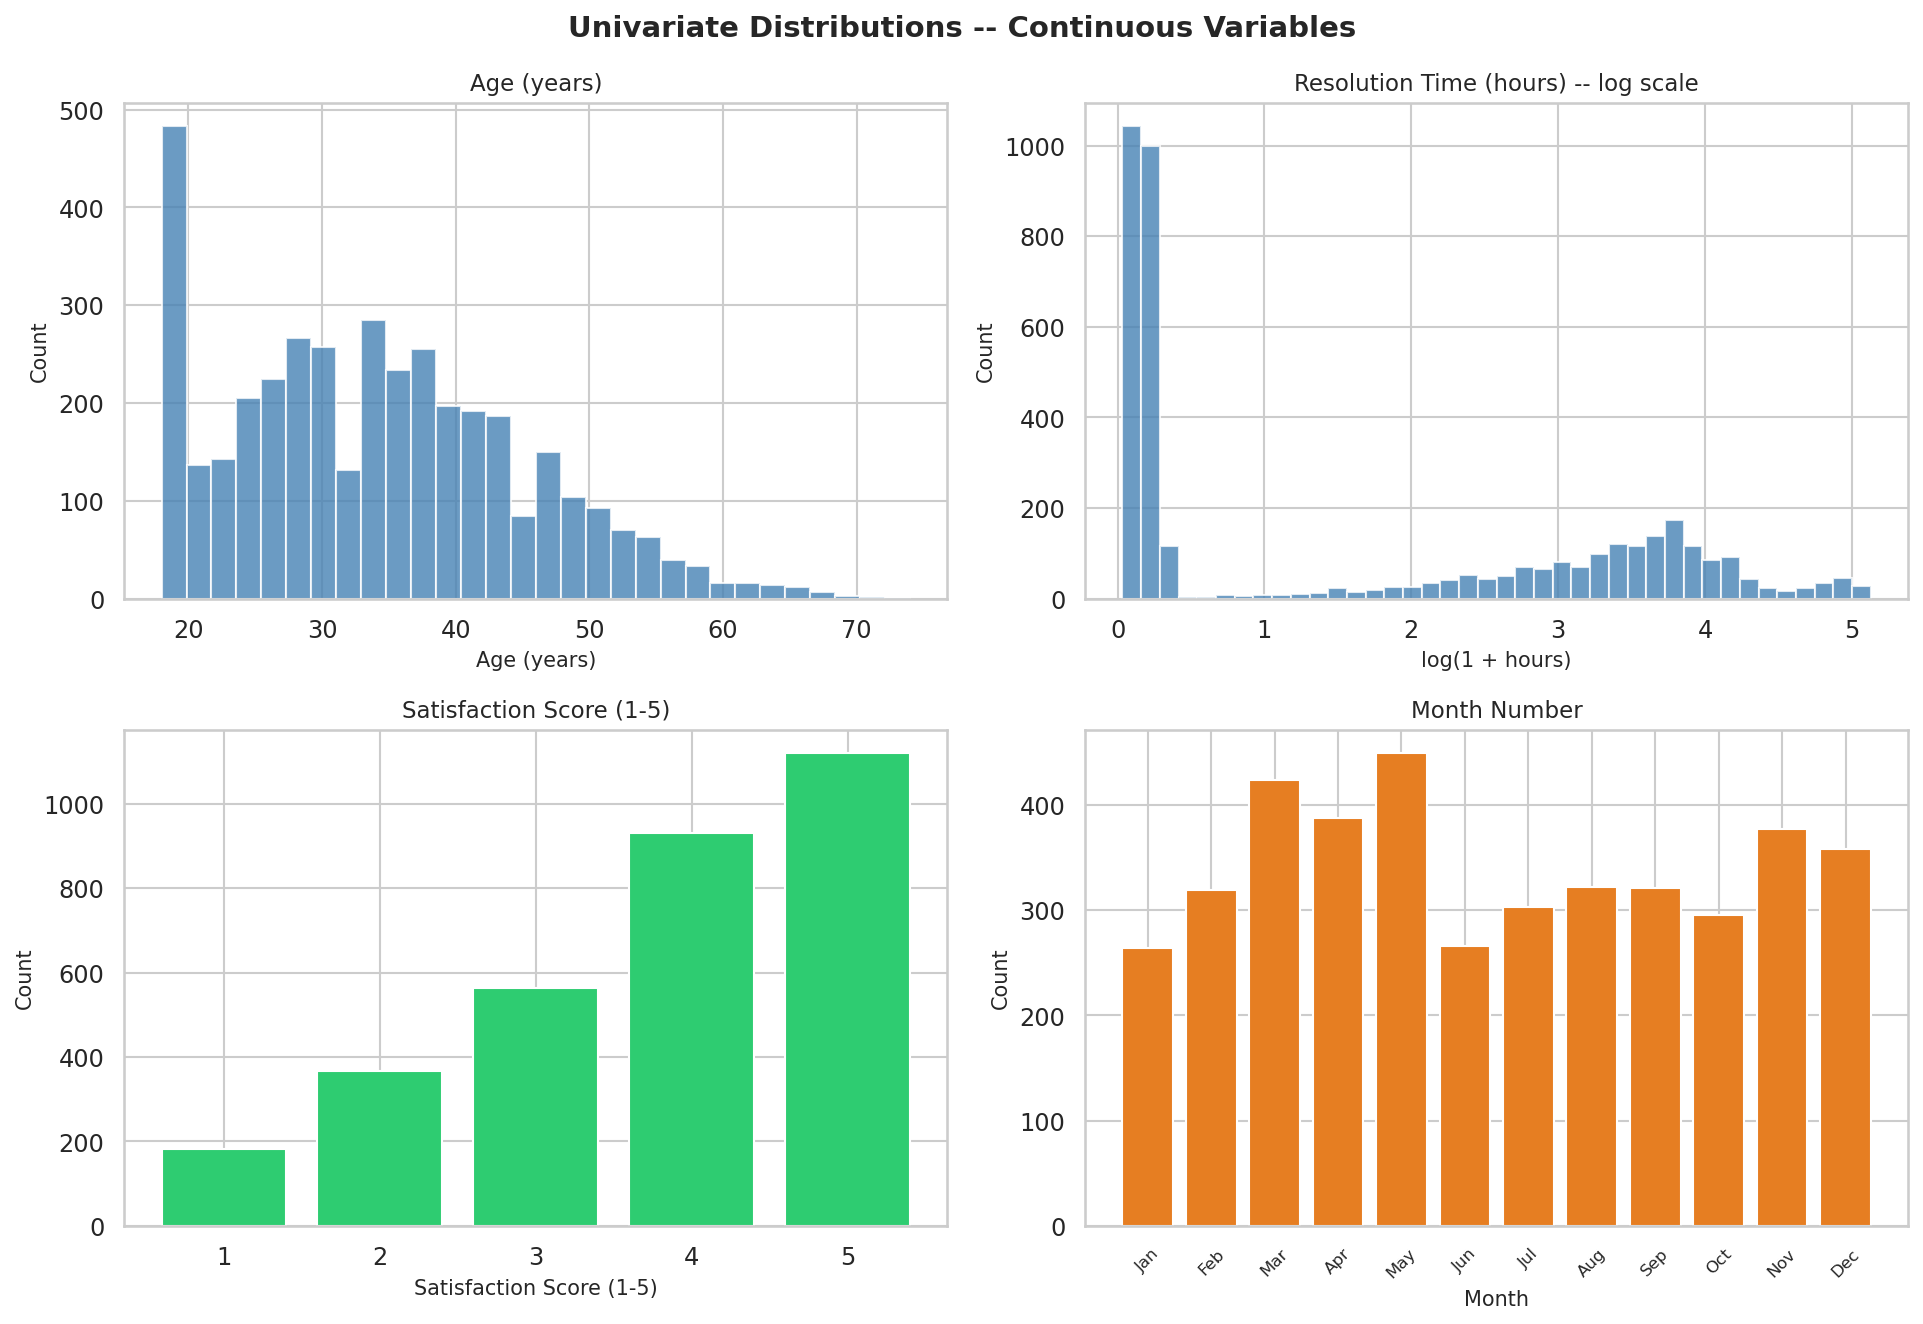

In [21]:
# -----------------------------------------------------------------------
# Univariate charts: histograms for continuous variables
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Univariate Distributions -- Continuous Variables',
             fontsize=14, fontweight='bold')

plot_cfg = [
    ('age', 'Age (years)', axes[0, 0]),
    ('resolution_time_hours', 'Resolution Time (hours) -- log scale', axes[0, 1]),
    ('satisfaction_score', 'Satisfaction Score (1-5)', axes[1, 0]),
    ('month_num', 'Month Number', axes[1, 1]),
]

for col, xlabel, ax in plot_cfg:
    data = df[col].dropna()
    if col == 'resolution_time_hours':
        ax.hist(np.log1p(data), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_xlabel('log(1 + hours)', fontsize=10)
    elif col == 'satisfaction_score':
        counts = data.value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='#2ecc71', edgecolor='white')
        ax.set_xlabel(xlabel, fontsize=10)
    elif col == 'month_num':
        counts = data.value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='#e67e22', edgecolor='white')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(MONTH_LABELS, rotation=45, fontsize=8)
        ax.set_xlabel('Month', fontsize=10)
    else:
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(xlabel, fontsize=11)

fig.tight_layout()
save_fig(fig, '00a_univariate_distributions.png')


---
## Supplementary EDA — Bivariate Analysis
Cross-variable relationships relevant to the regulatory brief.

In [22]:
# -----------------------------------------------------------------------
# Bivariate 1: Resolution time x complaint category
# -----------------------------------------------------------------------
biv1 = (
    df.groupby('complaint_category')['resolution_time_hours']
      .describe(percentiles=[.25, .5, .75])
      .round(2)
      .sort_values('50%', ascending=False)
)
print('--- Resolution Time (hours) by Complaint Category ---')
display(biv1)


--- Resolution Time (hours) by Complaint Category ---


,count,mean,std,min,25%,50%,75%,max
complaint_category,,,,,,,,
Fraud,384.0,25.24,23.46,0.08,0.23,20.04,47.25,71.55
Other,74.0,21.84,33.13,0.03,0.19,3.22,34.92,156.62
Device,128.0,20.02,33.76,0.03,0.15,0.33,31.02,167.67
Billing,481.0,18.40,29.03,0.03,0.17,0.32,32.92,161.83
Network,204.0,19.81,33.02,0.03,0.20,0.32,30.12,163.08
Data/Internet,594.0,17.60,31.49,0.03,0.18,0.30,26.88,167.83
Mobile Money,987.0,16.96,29.62,0.03,0.17,0.30,26.66,165.03
SIM Issues,322.0,15.54,27.89,0.03,0.15,0.30,21.72,167.53
VAS,192.0,14.99,26.95,0.03,0.15,0.28,22.48,158.98


In [23]:
# -----------------------------------------------------------------------
# Bivariate 2: Satisfaction score x provider
# -----------------------------------------------------------------------
biv2 = (
    df.groupby('provider')['satisfaction_score']
      .agg(['count', 'mean', 'median', 'std'])
      .round(2)
      .sort_values('mean', ascending=False)
)
print('--- Satisfaction Score by Provider ---')
display(biv2)
print()
print('Means and medians are basically the same across providers -- matches the')
print("Kruskal-Wallis result above. Satisfaction doesn't track with provider here.")


--- Satisfaction Score by Provider ---


,count,mean,median,std
provider,,,,
Glo,367,3.84,4.0,1.18
Airtel,1147,3.77,4.0,1.22
MTN,1424,3.76,4.0,1.22
9Mobile,227,3.74,4.0,1.16



Means and medians are basically the same across providers -- matches the
Kruskal-Wallis result above. Satisfaction doesn't track with provider here.


In [24]:
# -----------------------------------------------------------------------
# Bivariate 3: Channel x status (resolution rate)
# -----------------------------------------------------------------------
biv3 = pd.crosstab(df['channel'], df['status'],
                   normalize='index').mul(100).round(1)
print('--- Resolution Status by Channel (% within each channel) ---')
display(biv3)
print()
print('Call Center has by far the highest Resolved share -- every other channel')
print('closes under 60% of complaints. Same story as the FCR gap in Task 2.2:')
print("Call Center isn't just faster, it actually closes more complaints. The")
print('other channels look under-resourced and could use their own service standards.')


--- Resolution Status by Channel (% within each channel) ---


status,Escalated,Pending,Resolved
channel,,,
Call Center,6.1,9.7,84.3
Email,20.6,30.0,49.4
In-Person,23.1,29.2,47.7
Social Media,18.5,34.2,47.3
USSD,13.9,28.7,57.4



Call Center has by far the highest Resolved share -- every other channel
closes under 60% of complaints. Same story as the FCR gap in Task 2.2:
Call Center isn't just faster, it actually closes more complaints. The
other channels look under-resourced and could use their own service standards.


In [25]:
# -----------------------------------------------------------------------
# Bivariate 4: Fraud complaints x hour of day
# -----------------------------------------------------------------------
fraud = df[df['complaint_category'] == 'Fraud']
hourly_fraud  = fraud.groupby('hour').size()
total_hourly  = df.groupby('hour').size()
fraud_share   = (hourly_fraud / total_hourly * 100).dropna().round(1)

print('--- Fraud Complaint Share by Hour of Day (%) ---')
for h in range(0, 24):
    share = fraud_share.get(h, 0)
    bar   = '#' * int(share)
    print(f'  {h:02d}:00  {share:4.1f}%  {bar}')
print()
print('Peak fraud hours:', fraud_share.nlargest(3).to_dict())
print()
print(f'Range: {fraud_share.min():.1f}%-{fraud_share.max():.1f}% -- pretty flat, no real')
print("time-of-day pattern here (also worth noting complaints only get logged 06:00-22:00,")
print("so there's no overnight window to even compare against).")


--- Fraud Complaint Share by Hour of Day (%) ---
  00:00   0.0%  
  01:00   0.0%  
  02:00   0.0%  
  03:00   0.0%  
  04:00   0.0%  
  05:00   0.0%  
  06:00   8.1%  ########
  07:00   6.8%  ######
  08:00   9.3%  #########
  09:00  13.0%  #############
  10:00   9.2%  #########
  11:00   9.2%  #########
  12:00   6.6%  ######
  13:00   8.5%  ########
  14:00   9.7%  #########
  15:00   8.5%  ########
  16:00  10.9%  ##########
  17:00  13.7%  #############
  18:00   8.1%  ########
  19:00   8.4%  ########
  20:00  11.9%  ###########
  21:00  10.5%  ##########
  22:00  10.0%  ##########
  23:00   0.0%  

Peak fraud hours: {17: 13.7, 9: 13.0, 20: 11.9}

Range: 6.6%-13.7% -- pretty flat, no real
time-of-day pattern here (also worth noting complaints only get logged 06:00-22:00,
so there's no overnight window to even compare against).


In [26]:
# -----------------------------------------------------------------------
# Bivariate 5: Gender x FCR rate
# -----------------------------------------------------------------------
biv5 = (
    df.groupby('gender')['fcr']
      .agg(Total='count', FCR_Count='sum')
      .assign(**{'FCR_Rate_pct': lambda x: (x['FCR_Count'] / x['Total'] * 100).round(1)})
)
print('--- FCR Rate by Gender ---')
display(biv5)
print()
gap = biv5['FCR_Rate_pct'].max() - biv5['FCR_Rate_pct'].min()
print(f"Only {gap:.1f} points apart -- gender doesn't really affect how fast a complaint gets resolved.")


--- FCR Rate by Gender ---


,Total,FCR_Count,FCR_Rate_pct
gender,,,
Female,1515,594,39.2
Male,2353,945,40.2



Only 1.0 points apart -- gender doesn't really affect how fast a complaint gets resolved.


In [27]:
# -----------------------------------------------------------------------
# Bivariate 6: Age x complaint category (median age per category)
# -----------------------------------------------------------------------
biv6 = (
    df.groupby('complaint_category')['age']
      .agg(['count', 'mean', 'median'])
      .round(1)
      .sort_values('median', ascending=False)
)
print('--- Complainant Age by Category (years) ---')
display(biv6)
print()
overall_median_age = df['age'].median()
print(f"Overall median age is {overall_median_age:.0f}, and it's pretty flat across")
print(f'categories (32-34) except "Other" which skews older (median '
      f'{biv6.loc["Other", "median"]:.0f}). Fraud complainants (median '
      f'{biv6.loc["Fraud", "median"]:.0f}) are barely older than average -- age')
print("isn't much of a fraud signal on its own here.")


--- Complainant Age by Category (years) ---


,count,mean,median
complaint_category,,,
Other,69,37.3,38.0
Fraud,372,34.8,34.0
SIM Issues,319,34.1,34.0
VAS,189,34.1,34.0
Billing,476,33.9,33.0
Data/Internet,582,34.0,33.0
Mobile Money,954,33.9,33.0
Network,198,34.5,33.0
Voice/Calls,626,33.8,33.0



Overall median age is 33, and it's pretty flat across
categories (32-34) except "Other" which skews older (median 38). Fraud complainants (median 34) are barely older than average -- age
isn't much of a fraud signal on its own here.


---
## Part 3 — Data Visualisation
### Task 3.1  Monthly Complaints Trend (Line Chart)

  Saved: C:\Users\USER\Desktop\ioppppaaaa2\charts\01_monthly_trend.png


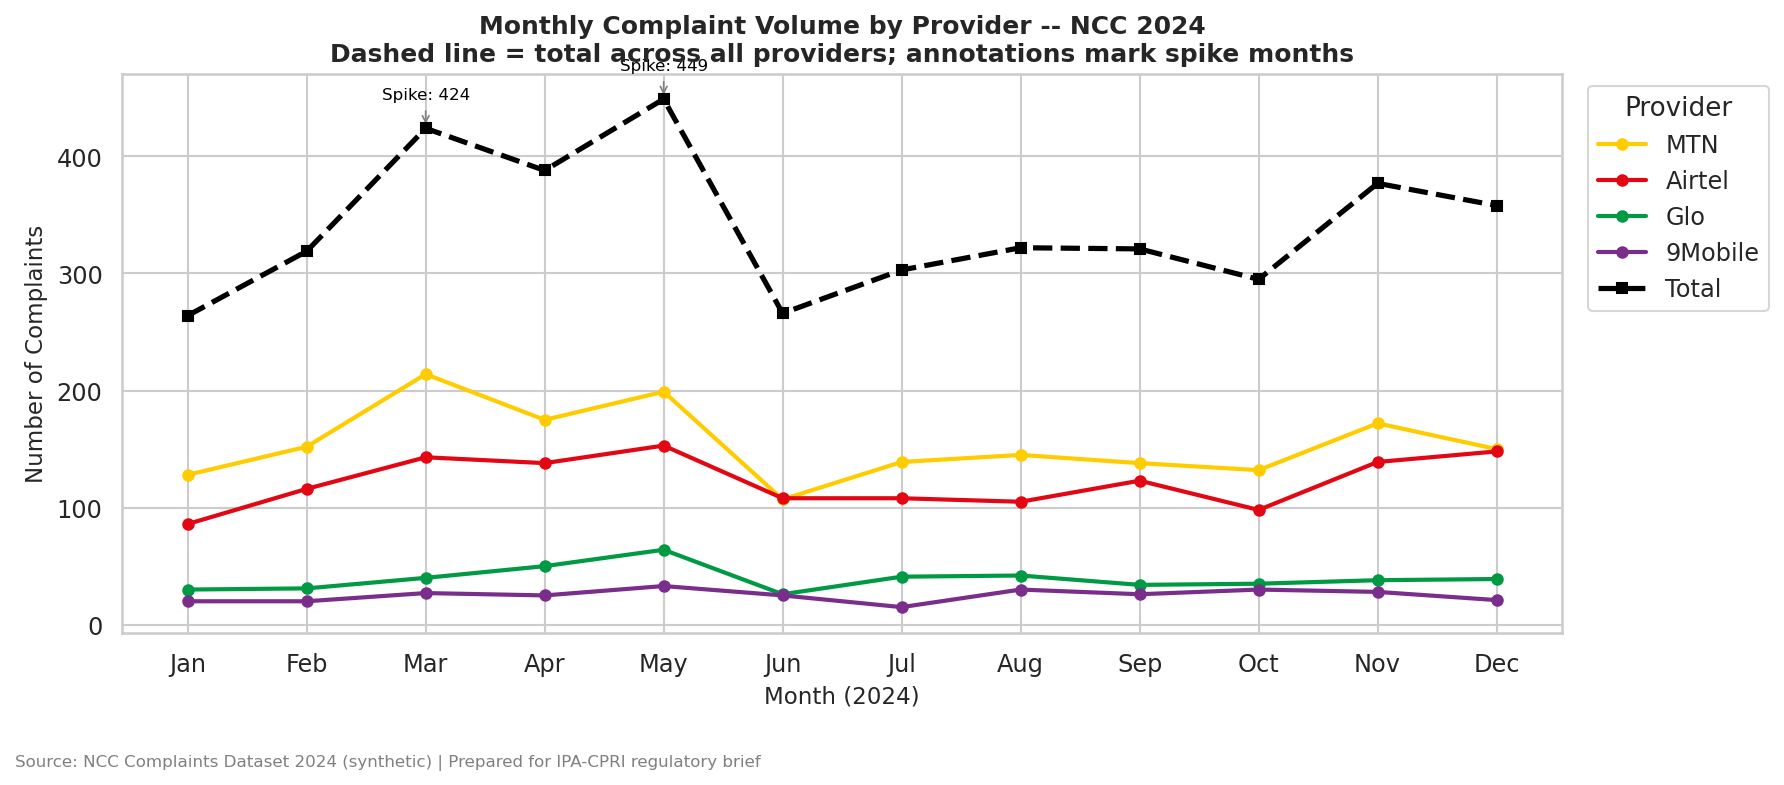

In [28]:
# -----------------------------------------------------------------------
# Task 3.1 -- Monthly complaints trend: total + per provider
# -----------------------------------------------------------------------
pivot = (
    df.groupby(['month_num', 'provider'])
      .size()
      .unstack(fill_value=0)
      .reindex(range(1, 13), fill_value=0)
)
total_monthly = pivot.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))

for prov in ['MTN', 'Airtel', 'Glo', '9Mobile']:
    if prov in pivot.columns:
        ax.plot(pivot.index, pivot[prov],
                marker='o', linewidth=2, markersize=5,
                color=PROVIDER_COLORS[prov], label=prov)

ax.plot(pivot.index, total_monthly, color='black',
        linewidth=2.5, linestyle='--', marker='s',
        markersize=5, label='Total', zorder=5)

# Annotate spike months (>mean + 1 std)
mean_v = total_monthly.mean()
std_v  = total_monthly.std()
for m, v in total_monthly.items():
    if v > mean_v + std_v:
        ax.annotate(
            f'Spike: {v}',
            xy=(m, v), xytext=(0, 14), textcoords='offset points',
            ha='center', fontsize=8, color='black',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8)
        )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel('Month (2024)', fontsize=11)
ax.set_ylabel('Number of Complaints', fontsize=11)
ax.set_title(
    'Monthly Complaint Volume by Provider -- NCC 2024\n'
    'Dashed line = total across all providers; annotations mark spike months',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Provider', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.text(0.01, -0.04,
    'Source: NCC Complaints Dataset 2024 (synthetic) | Prepared for IPA-CPRI regulatory brief',
    fontsize=8, color='grey')

fig.tight_layout()
save_fig(fig, '01_monthly_trend.png')


### Task 3.2  Complaint Categories by Provider (Grouped Bar)

  Saved: C:\Users\USER\Desktop\ioppppaaaa2\charts\02_category_by_provider.png


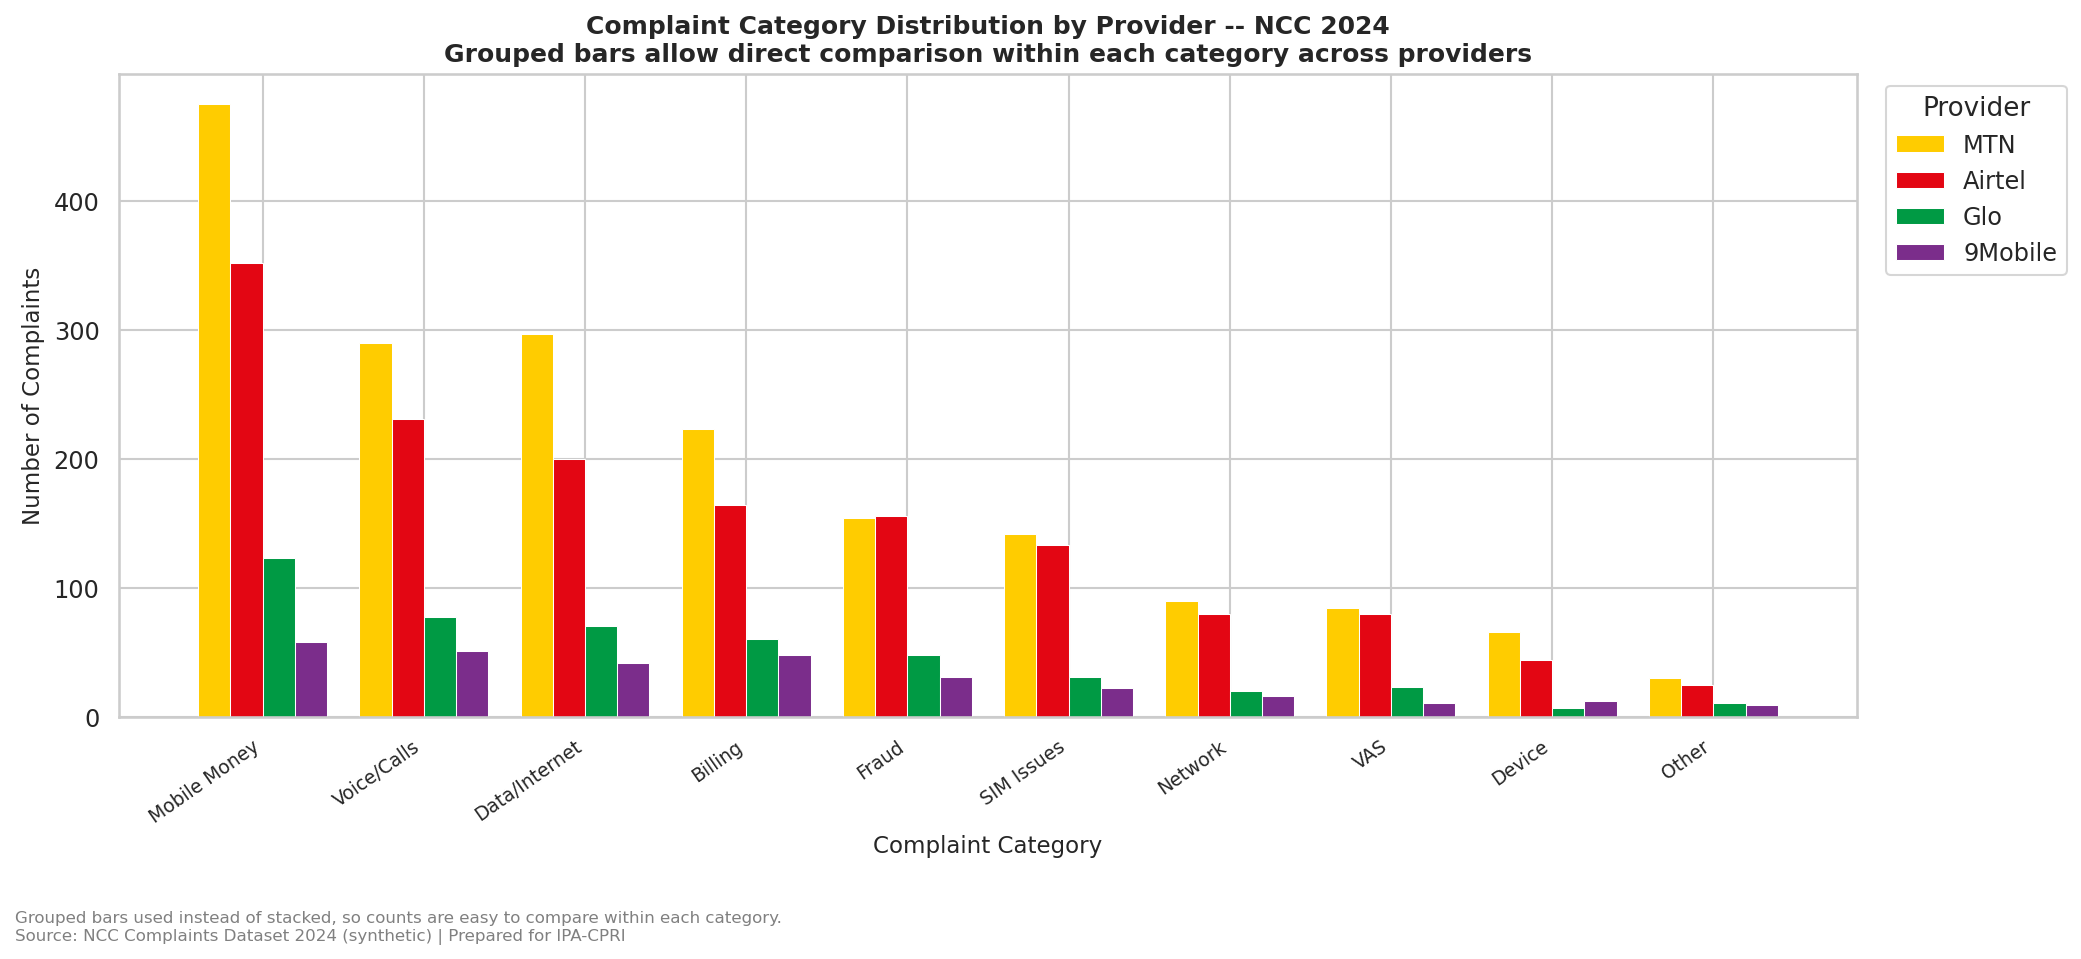

In [29]:
# -----------------------------------------------------------------------
# Task 3.2 -- Grouped bar chart: category distribution by provider
# Grouped rather than stacked, so it's easy to compare providers within
# each category (stacked bars make that comparison harder to read).
# -----------------------------------------------------------------------
cat_piv = (
    df.groupby(['complaint_category', 'provider'])
      .size()
      .unstack(fill_value=0)
)
# Order categories by total volume
cat_piv = cat_piv.loc[cat_piv.sum(axis=1).sort_values(ascending=False).index]

PROVIDERS = ['MTN', 'Airtel', 'Glo', '9Mobile']
n_cats = len(cat_piv)
x = np.arange(n_cats)
bar_w = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, prov in enumerate(PROVIDERS):
    vals = [int(cat_piv.loc[cat, prov]) if prov in cat_piv.columns else 0
            for cat in cat_piv.index]
    ax.bar(x + i * bar_w, vals, bar_w,
           label=prov, color=PROVIDER_COLORS[prov],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + bar_w * (len(PROVIDERS) - 1) / 2)
ax.set_xticklabels(cat_piv.index, rotation=35, ha='right', fontsize=9)
ax.set_xlabel('Complaint Category', fontsize=11)
ax.set_ylabel('Number of Complaints', fontsize=11)
ax.set_title(
    'Complaint Category Distribution by Provider -- NCC 2024\n'
    'Grouped bars allow direct comparison within each category across providers',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Provider', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.text(0.01, -0.06,
    'Grouped bars used instead of stacked, so counts are easy to compare within each category.\n'
    'Source: NCC Complaints Dataset 2024 (synthetic) | Prepared for IPA-CPRI',
    fontsize=8, color='grey')

fig.tight_layout()
save_fig(fig, '02_category_by_provider.png')


### Task 3.3  Resolution Performance Dashboard

  Saved: C:\Users\USER\Desktop\ioppppaaaa2\charts\03_resolution_dashboard.png


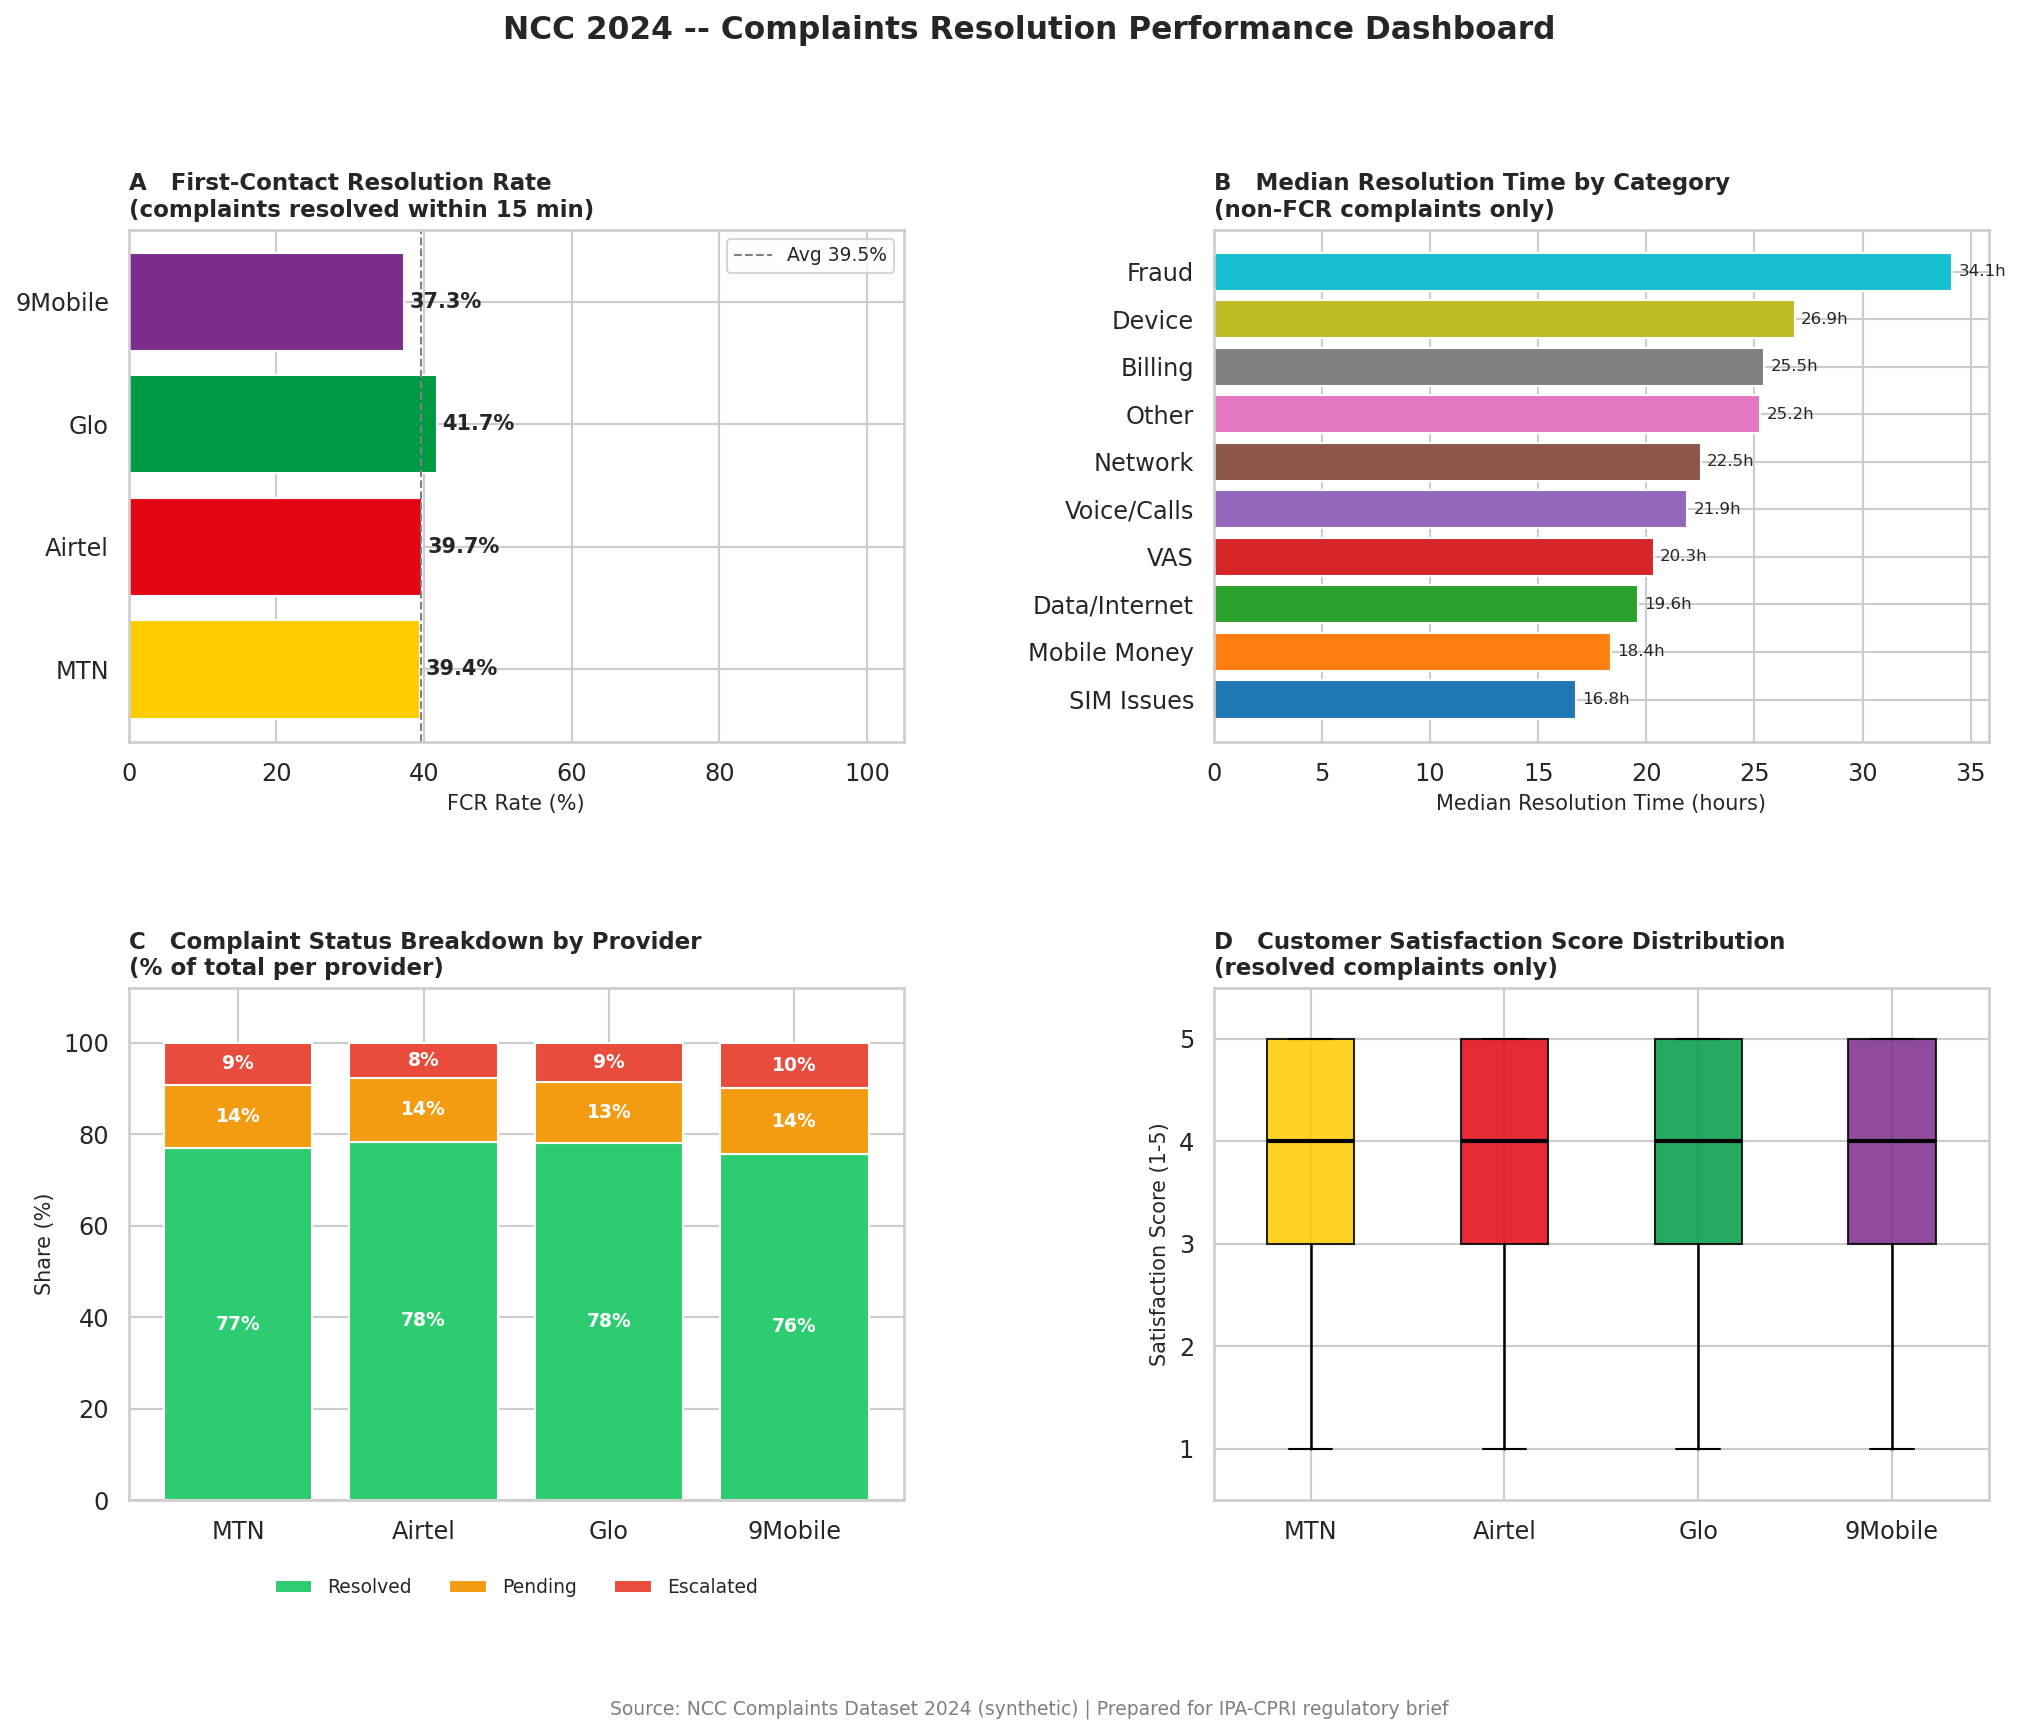

In [30]:
# -----------------------------------------------------------------------
# Task 3.3 -- 2x2 Resolution performance dashboard
# Panels: A=FCR rate | B=Median resolution time | C=Status breakdown | D=Satisfaction
# -----------------------------------------------------------------------
PROV_ORDER = ['MTN', 'Airtel', 'Glo', '9Mobile']
PROV_CLR   = [PROVIDER_COLORS[p] for p in PROV_ORDER]

fig = plt.figure(figsize=(16, 11))
gs  = GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.40)

# -- Panel A: FCR Rate by Provider ----------------------------------------
ax_a = fig.add_subplot(gs[0, 0])
fcr_vals = []
for p in PROV_ORDER:
    sub  = df[df['provider'] == p]
    rate = sub['fcr'].mean() * 100 if len(sub) > 0 else 0
    fcr_vals.append(round(rate, 1))

bars = ax_a.barh(PROV_ORDER, fcr_vals, color=PROV_CLR, edgecolor='white')
for bar, val in zip(bars, fcr_vals):
    ax_a.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
avg_fcr = sum(fcr_vals) / len(fcr_vals)
ax_a.axvline(x=avg_fcr, color='grey', linestyle='--', linewidth=1,
             label=f'Avg {avg_fcr:.1f}%')
ax_a.set_xlim(0, 105)
ax_a.set_xlabel('FCR Rate (%)', fontsize=10)
ax_a.set_title('A   First-Contact Resolution Rate\n(complaints resolved within 15 min)',
               fontsize=11, fontweight='bold', loc='left')
ax_a.legend(fontsize=9)

# -- Panel B: Median resolution time by category --------------------------
ax_b = fig.add_subplot(gs[0, 1])
non_fcr_b = df[
    (df['resolution_time_minutes'] > 15) &
    df['resolution_time_minutes'].notna()
]
med_b = (
    non_fcr_b.groupby('complaint_category')['resolution_time_hours']
             .median()
             .sort_values(ascending=True)
)
colors_b = [CATEGORY_PALETTE[i % 10] for i in range(len(med_b))]
bars_b = ax_b.barh(med_b.index, med_b.values, color=colors_b)
for bar, val in zip(bars_b, med_b.values):
    ax_b.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}h', va='center', fontsize=8)
ax_b.set_xlabel('Median Resolution Time (hours)', fontsize=10)
ax_b.set_title('B   Median Resolution Time by Category\n(non-FCR complaints only)',
               fontsize=11, fontweight='bold', loc='left')

# -- Panel C: Status breakdown by provider --------------------------------
ax_c = fig.add_subplot(gs[1, 0])
status_piv = (
    df.groupby(['provider', 'status'])
      .size()
      .unstack(fill_value=0)
      .reindex(PROV_ORDER)
)
status_pct = status_piv.div(status_piv.sum(axis=1), axis=0).mul(100)
STATUS_CLR = {'Resolved': '#2ecc71', 'Pending': '#f39c12', 'Escalated': '#e74c3c'}

bottom = np.zeros(len(PROV_ORDER))
for status in ['Resolved', 'Pending', 'Escalated']:
    if status in status_pct.columns:
        vals = status_pct[status].values
        ax_c.bar(PROV_ORDER, vals, bottom=bottom,
                 color=STATUS_CLR[status], label=status, edgecolor='white')
        for j, (b, v) in enumerate(zip(bottom, vals)):
            if v > 4:
                ax_c.text(j, b + v / 2, f'{v:.0f}%',
                          ha='center', va='center', fontsize=9,
                          color='white', fontweight='bold')
        bottom += vals

ax_c.set_ylim(0, 112)
ax_c.set_ylabel('Share (%)', fontsize=10)
ax_c.set_title('C   Complaint Status Breakdown by Provider\n(% of total per provider)',
               fontsize=11, fontweight='bold', loc='left')
ax_c.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9, frameon=False)

# -- Panel D: Satisfaction score distribution (box plots) -----------------
ax_d = fig.add_subplot(gs[1, 1])
sat_by_prov = [
    df.loc[df['provider'] == p, 'satisfaction_score'].dropna().values
    for p in PROV_ORDER
]
bp = ax_d.boxplot(
    sat_by_prov, patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, clr in zip(bp['boxes'], PROV_CLR):
    patch.set_facecolor(clr)
    patch.set_alpha(0.85)

ax_d.set_xticks(range(1, 5))
ax_d.set_xticklabels(PROV_ORDER)
ax_d.set_ylim(0.5, 5.5)
ax_d.set_yticks(range(1, 6))
ax_d.set_ylabel('Satisfaction Score (1-5)', fontsize=10)
ax_d.set_title('D   Customer Satisfaction Score Distribution\n(resolved complaints only)',
               fontsize=11, fontweight='bold', loc='left')

fig.suptitle('NCC 2024 -- Complaints Resolution Performance Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
fig.text(0.5, -0.02,
    'Source: NCC Complaints Dataset 2024 (synthetic) | Prepared for IPA-CPRI regulatory brief',
    ha='center', fontsize=9, color='grey')

save_fig(fig, '03_resolution_dashboard.png')


### Task 3.4  Geographic Distribution

  Saved: C:\Users\USER\Desktop\ioppppaaaa2\charts\04_geographic_distribution.png


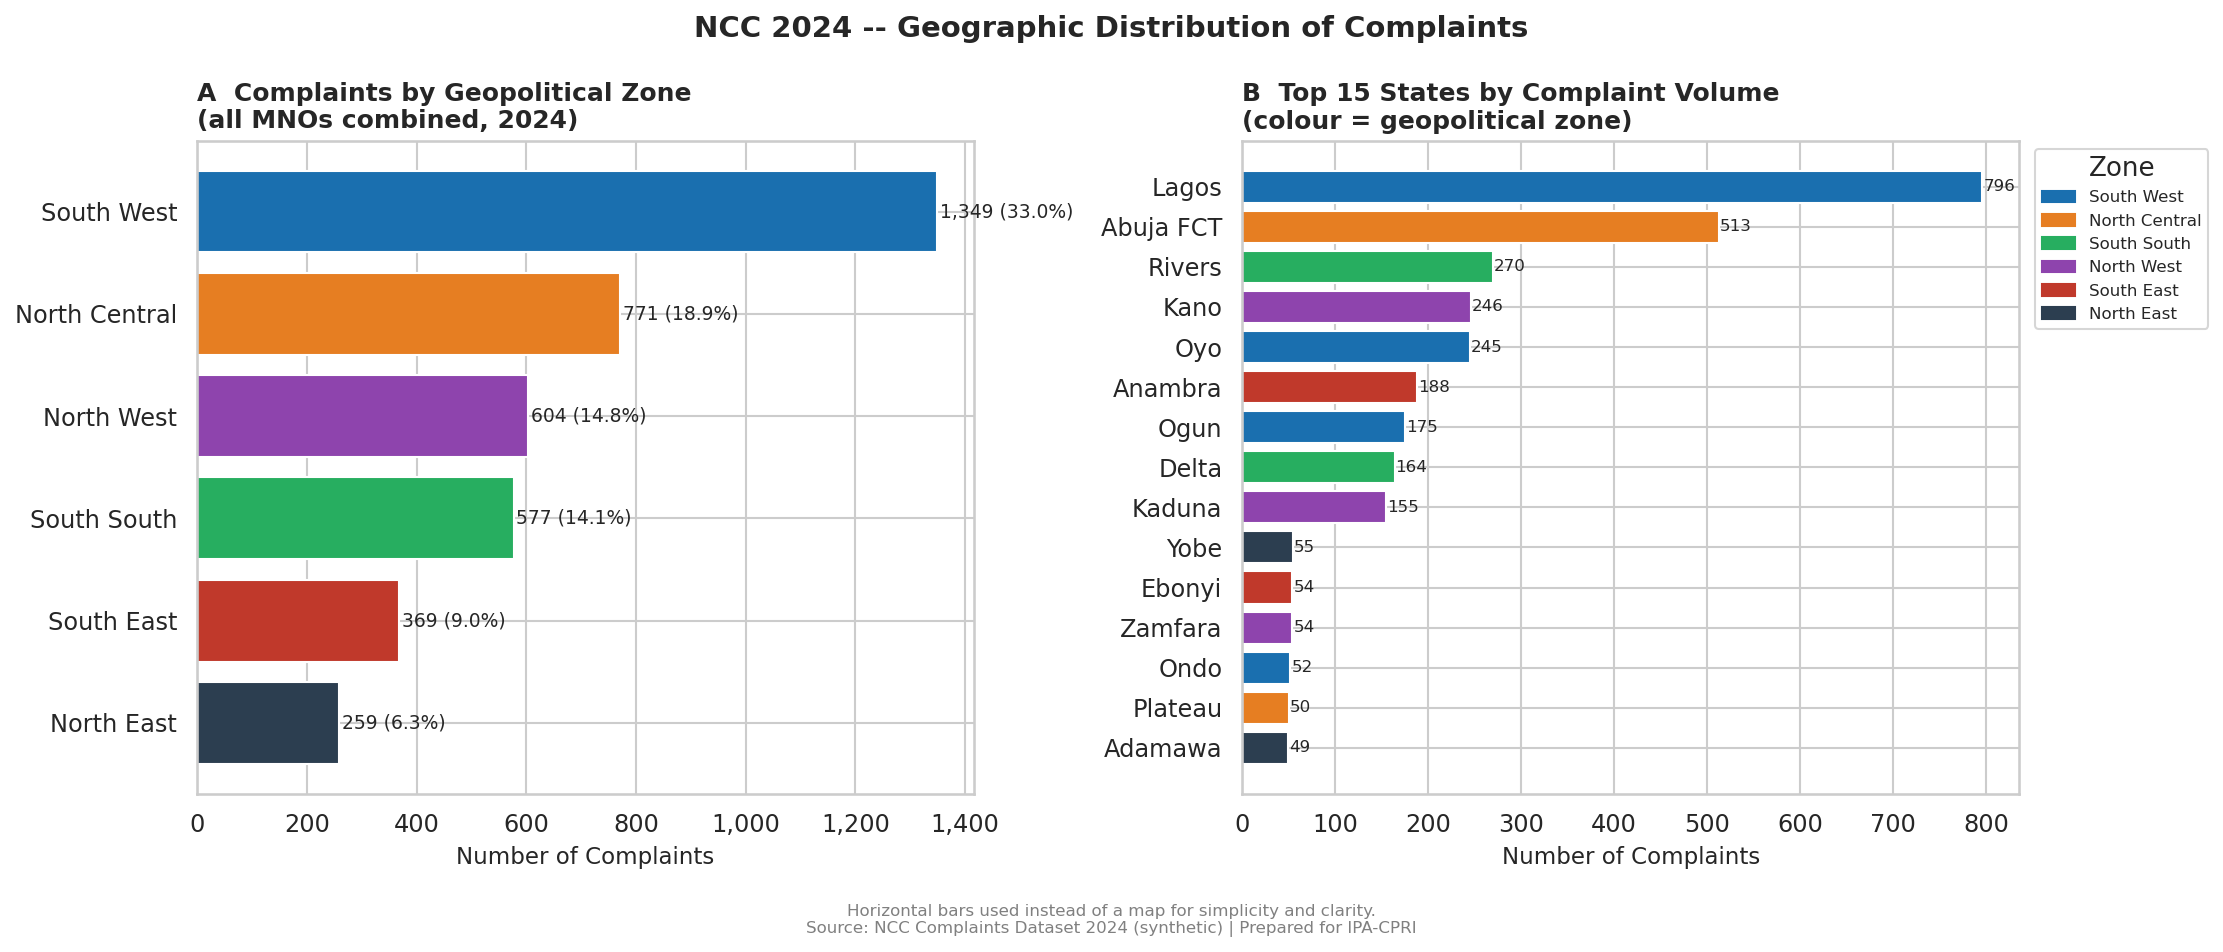

In [31]:
# -----------------------------------------------------------------------
# Task 3.4 -- Geographic distribution
# Using horizontal bar charts (zone + top states) instead of a map -- a map
# needs a shapefile and doesn't add much clarity for this audience anyway.
# -----------------------------------------------------------------------
zone_vc = df['geopolitical_zone'].value_counts(dropna=True).sort_values()

ZONE_CLR = {
    'South West':    '#1a6faf',
    'North Central': '#e67e22',
    'South South':   '#27ae60',
    'North West':    '#8e44ad',
    'South East':    '#c0392b',
    'North East':    '#2c3e50',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: zones
ax1 = axes[0]
colors_z = [ZONE_CLR.get(str(z), '#7f8c8d') for z in zone_vc.index]
bars_z = ax1.barh(zone_vc.index.astype(str), zone_vc.values,
                  color=colors_z, edgecolor='white')
for bar, val in zip(bars_z, zone_vc.values):
    pct = val / len(df) * 100  # % of ALL records (incl. missing zone) -- matches Task 2.3b
    ax1.text(val + 5, bar.get_y() + bar.get_height() / 2,
             f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
ax1.set_xlabel('Number of Complaints', fontsize=11)
ax1.set_title('A  Complaints by Geopolitical Zone\n(all MNOs combined, 2024)',
              fontsize=12, fontweight='bold', loc='left')
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right panel: top 15 states
ax2 = axes[1]
top_states = df['state'].value_counts().head(15).sort_values()

def get_zone_color(state):
    sub = df.loc[df['state'] == state, 'geopolitical_zone'].dropna()
    if len(sub) == 0:
        return '#7f8c8d'
    zone = sub.mode()[0]
    return ZONE_CLR.get(zone, '#7f8c8d')

colors_s = [get_zone_color(s) for s in top_states.index]
bars_s = ax2.barh(top_states.index.astype(str), top_states.values,
                  color=colors_s, edgecolor='white')
for bar, val in zip(bars_s, top_states.values):
    ax2.text(val + 1, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=8)
ax2.set_xlabel('Number of Complaints', fontsize=11)
ax2.set_title('B  Top 15 States by Complaint Volume\n(colour = geopolitical zone)',
              fontsize=12, fontweight='bold', loc='left')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

legend_patches = [mpatches.Patch(color=c, label=z) for z, c in ZONE_CLR.items()]
ax2.legend(handles=legend_patches, title='Zone',
           bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

fig.suptitle('NCC 2024 -- Geographic Distribution of Complaints',
             fontsize=14, fontweight='bold')
fig.text(0.5, -0.04,
    'Horizontal bars used instead of a map for simplicity and clarity.\n'
    'Source: NCC Complaints Dataset 2024 (synthetic) | Prepared for IPA-CPRI',
    ha='center', fontsize=8, color='grey')

fig.tight_layout()
save_fig(fig, '04_geographic_distribution.png')


---
## Bonus — Fraud Deep-Dive
Directly relevant to NCC consumer protection mandate.

  Saved: C:\Users\USER\Desktop\ioppppaaaa2\charts\05_fraud_deepdive.png


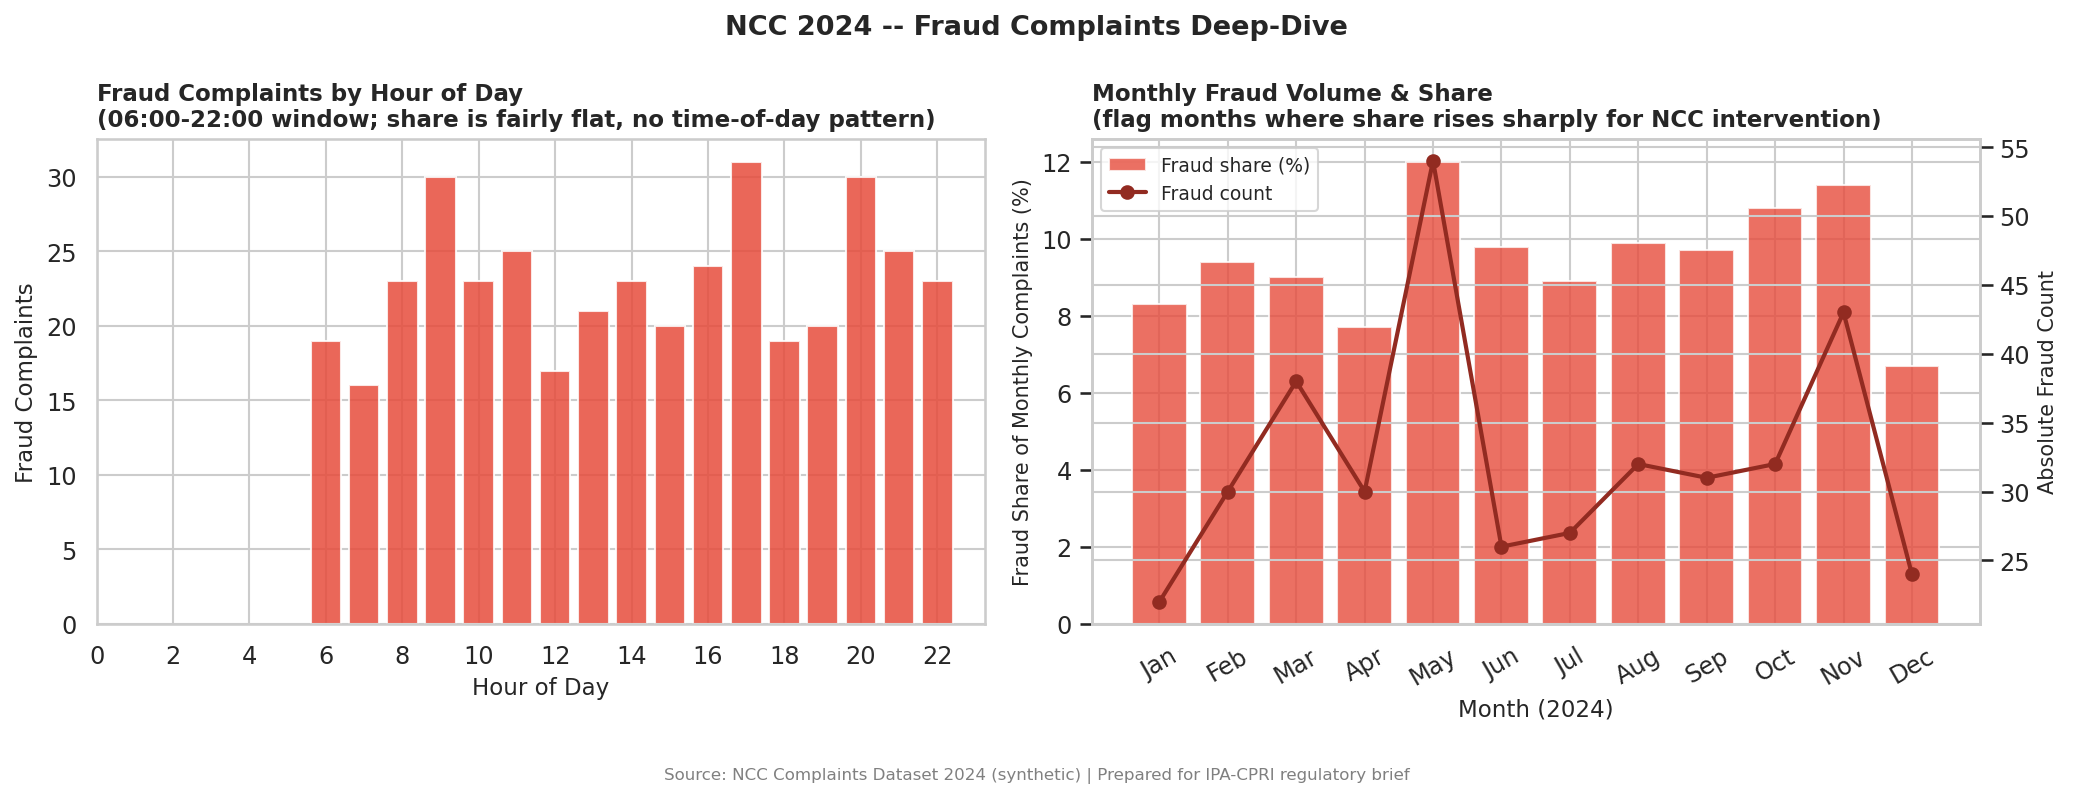


Fraud share stays in a narrow band (6.6%-13.7%) across the 06:00-22:00 window complaints are
logged in -- no real time-of-day pattern here. With only 389 fraud cases in a
year, that could just be limited data rather than a genuine absence of a
pattern, so worth keeping an eye on rather than ruling it out.


In [32]:
# -----------------------------------------------------------------------
# Fraud deep-dive: hourly pattern + monthly trend
# -----------------------------------------------------------------------
fraud_df = df[df['complaint_category'] == 'Fraud'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly distribution
ax1 = axes[0]
hourly = fraud_df.groupby('hour').size()
ax1.bar(hourly.index, hourly.values,
        color='#e74c3c', edgecolor='white', alpha=0.85)
ax1.set_xticks(range(0, 24, 2))
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Fraud Complaints', fontsize=11)
ax1.set_title(
    'Fraud Complaints by Hour of Day\n'
    '(06:00-22:00 window; share is fairly flat, no time-of-day pattern)',
    fontsize=11, fontweight='bold', loc='left'
)

# Monthly fraud share vs total
ax2 = axes[1]
fraud_monthly  = fraud_df.groupby('month_num').size().reindex(range(1, 13), fill_value=0)
total_monthly2 = df.groupby('month_num').size().reindex(range(1, 13), fill_value=0)
fraud_share_m  = (fraud_monthly / total_monthly2 * 100).round(1)

ax2.bar(range(1, 13), fraud_share_m.values,
        color='#e74c3c', alpha=0.8, edgecolor='white', label='Fraud share (%)')
ax2_twin = ax2.twinx()
ax2_twin.plot(range(1, 13), fraud_monthly.values,
              color='#922b21', marker='o', linewidth=2, label='Fraud count')

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_LABELS, rotation=30)
ax2.set_xlabel('Month (2024)', fontsize=11)
ax2.set_ylabel('Fraud Share of Monthly Complaints (%)', fontsize=10)
ax2_twin.set_ylabel('Absolute Fraud Count', fontsize=10)
ax2.set_title(
    'Monthly Fraud Volume & Share\n'
    '(flag months where share rises sharply for NCC intervention)',
    fontsize=11, fontweight='bold', loc='left'
)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

fig.suptitle('NCC 2024 -- Fraud Complaints Deep-Dive',
             fontsize=13, fontweight='bold')
fig.text(0.5, -0.04,
    'Source: NCC Complaints Dataset 2024 (synthetic) | Prepared for IPA-CPRI regulatory brief',
    ha='center', fontsize=8, color='grey')

fig.tight_layout()
save_fig(fig, '05_fraud_deepdive.png')

print()
fraud_hourly_share = (fraud_df.groupby('hour').size() / df.groupby('hour').size() * 100).dropna()
print(f'Fraud share stays in a narrow band ({fraud_hourly_share.min():.1f}%-'
      f'{fraud_hourly_share.max():.1f}%) across the 06:00-22:00 window complaints are')
print("logged in -- no real time-of-day pattern here. With only 389 fraud cases in a")
print('year, that could just be limited data rather than a genuine absence of a')
print('pattern, so worth keeping an eye on rather than ruling it out.')


---
## Written Summary — Key Findings for Regulatory Brief

### Context
This covers complaints lodged with Nigeria's four MNOs (MTN, Airtel, Glo, 9Mobile)
between January and December 2024, as recorded by the NCC. The raw file had 4,203
records; after cleaning, 4,086 unique complaints were left to work with.

### 1. Data cleaning
Provider names had six different spellings and casings across the four MNOs
("MTN Nigeria", "MTN NG", "mtn", "AIRTEL", "Airtel Nigeria", "airtel") and were
standardised. 117 records were exact duplicates and were dropped. 32 records had an
implausible age — below 15 or above 100, with values like -1, 5, 150 and 999 showing
up — and were set to missing rather than dropped. 89 records had a resolution date
earlier than the creation date; those two date fields were nulled, but the complaint
itself and its status were kept.

Two things are worth flagging as design choices in the data rather than quality
problems: `satisfaction_score` is only ever populated for Resolved complaints (100%
complete there, essentially 0% everywhere else), so it shouldn't be imputed. And
`state`/`geopolitical_zone` are missing together on the same 161 records, which looks
like an unregistered SIM rather than a random gap.

### 2. Complaint volumes
MTN (45.3%) and Airtel (35.9%) both file more complaints than their assumed market
share would suggest (40% and 27%) — and Airtel's gap (+8.9pp) is actually bigger than
MTN's (+5.3pp). Glo and 9Mobile sit below their expected share. The top categories
overall are Mobile Money (24.7%), Voice/Calls (15.9%), and Data/Internet (14.9%).

A chi-square test shows the mix of complaint types is not significantly different
across providers (p=0.13, Cramér's V=0.05). So the volume gaps above are really about
scale, not about one MNO having a different kind of problem than the others.

### 3. Resolution performance
FCR by provider is fairly tight (37.3%–41.7%) — not much of a story there. FCR by
channel is a different matter entirely: Call Center resolves 48.7% of complaints
within 15 minutes; every other channel manages only 1–3% (p<0.001). The same pattern
shows up in overall resolution rates — Call Center eventually closes 84.3% of its
complaints, versus 47–57% everywhere else. Channel, not provider, is what actually
drives resolution outcomes here.

Resolution time for complaints that don't get fixed in 15 minutes does differ
significantly by category (p<0.001): Fraud (34.1h median), Device (26.9h), and
Billing (25.5h) take the longest. Satisfaction scores, on the other hand, are
statistically the same across providers (p=0.60, all clustered around 3.7–3.8 out of
5) — once something gets resolved, people rate the experience about the same no
matter which network they're on.

### 4. Demographics and geography
Women make up 37.1% of complaints overall (39.2% of the ones with gender recorded),
against a rough 50/50 subscriber base. A one-proportion z-test says that gap is real
(p<0.0001), not noise. FCR barely differs by gender though (39.2% vs 40.2%), so this
looks like a gap in who's complaining rather than how they're treated once they do.

Geographically, South West (33.0%) and North Central (18.9%) together account for
over half of all complaints, with North East (6.3%) and South East (9.0%) the least
represented. Lagos and Abuja FCT alone make up about a third of the whole dataset.
Worth remembering this is complaint volume, not complaint rate — without subscriber
numbers by state it's hard to say how much of this reflects service quality versus
population density.

### 5. Time trends and fraud
Volume spiked in March (424) and May (449), both comfortably above the monthly
average of 340 — worth checking with the MNOs for outages or promotions around
those months, especially since May also had the year's highest fraud count (54).

On fraud specifically: complaints are only logged 06:00–22:00, and within that
window fraud's share stays in a fairly narrow band (6.6%–13.7%) with no clear
time-of-day pattern. With only 389 fraud cases across the year, this could simply be
a data-size issue rather than a genuine absence of a pattern, so it's worth
monitoring rather than concluding anything firm. Age doesn't say much about fraud
risk either — fraud complainants have a median age of 34, barely above the overall
median of 33.

### 6. A few caveats
This is synthetic data made for an assessment, so it's best treated as a
demonstration of approach rather than a real finding about the Nigerian market. A
single year isn't long enough to separate genuine seasonality from one-off events.
The market-share figures were supplied as rough benchmarks, not measured subscriber
data. And satisfaction scores only exist for resolved complaints, so people whose
issues never got fixed are invisible to that metric — meaning real satisfaction is
probably a bit lower than these numbers suggest.

### 7. Recommendations
1. **Set resolution-time standards by channel**, not just by provider. The FCR gap
   between Call Center and everything else (48.7% vs 1–3%) is the clearest pattern
   in the whole dataset.
2. **Require complete complainant data at the point of logging** — gender, age and
   state currently have gaps of 4–5% each.
3. **Set category-specific resolution targets**, especially for Fraud, Device and
   Billing, since those genuinely take longer to close.
4. **Look into the March and May spikes** with the MNOs before assuming they're
   just seasonal.
5. **Run outreach to female subscribers** on how and where to complain — the gap
   from 50/50 is statistically real, and it's a gap in who complains rather than
   how they're treated.

---
*Prepared by Tolulope Olowolaju for the IPA Nigeria CPRI Data Skills Assessment.*
